# Experimento 2: Sensibilidad del IRCT a la Variación de K

Este notebook evalúa cómo varía la calidad del clustering y el comportamiento del Índice de Resiliencia Territorial (IRCT) al usar distintos valores de k (número de clusters).

**Objetivo Principal:**
Identificar el valor óptimo de k que maximiza simultáneamente:
1. Calidad intrínseca del clustering (Silhouette, Davies-Bouldin, Calinski-Harabasz, Dunn Index)
2. Estabilidad global BASE → T585 (ARI, Jaccard, Drift)
3. Estabilidad y coherencia del IRCT (Mean, Std, CV, IQR)

**Metodología:**
Para cada k ∈ {2, 3, 4, 5, 6, 7, 8, 9, 10, 12, 15, 20} y cada modelo (AE/VAE) con **K-means y SOM**:
- Ajustar clustering en escenario BASE
- Calcular métricas de calidad intrínseca
- Calcular métricas de estabilidad BASE → T585
- Calcular IRCT y sus estadísticos
- Correlacionar métricas de clustering con comportamiento del IRCT
- Identificar k óptimo mediante ranking integrado

**Nota sobre DBSCAN:**
DBSCAN se **excluye** de este análisis porque:
- No respeta el parámetro K (solo depende de `eps` y `min_samples`)
- Encuentra el mismo número de clusters independientemente del K solicitado
- Generaría múltiples filas duplicadas que contaminarían el análisis K vs métricas
- Su inclusión sobrerrepresentaría artificialmente sus resultados en rankings y correlaciones

DBSCAN fue analizado en el Experimento 1 (comparación de métodos) y se determinó que no es adecuado para este tipo de análisis.

## 1. Imports y configuración

In [21]:
import os
import sys
import pickle
import glob
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from scipy.stats import percentileofscore, gaussian_kde
from scipy.special import softmax
import warnings
warnings.filterwarnings('ignore')

BASE_DIR = "/home/aninotna/magister/tesis/justh2_pipeline"
if BASE_DIR not in sys.path:
    sys.path.insert(0, BASE_DIR)

DATA_DIR = os.path.join(BASE_DIR, "data")
PLOTS_DIR = os.path.join(BASE_DIR, "plots", "clustering_k_sensitivity")
os.makedirs(PLOTS_DIR, exist_ok=True)

# Importar librerías modulares
from scripts.idroverdi_autoencoder_3.utils.clustering import cluster_and_measure_resilience, get_cluster_summary
from scripts.idroverdi_autoencoder_3.resilience_lib import (
    compute_IRCT_from_clustering_results,
    aggregate_IRCT_by_cluster
)

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

# Configuración de estilo de gráficos
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 12})

print(f"Imports completados")
print(f"Directorio de plots: {PLOTS_DIR}")
print(f"Seed: {SEED}")

Imports completados
Directorio de plots: /home/aninotna/magister/tesis/justh2_pipeline/plots/clustering_k_sensitivity
Seed: 42


## 2. Definición de arquitecturas AE y VAE

In [22]:
class AE(nn.Module):
    def __init__(self, input_dim, latent_dim=8, p_drop=0.1):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.BatchNorm1d(128),
            nn.LeakyReLU(0.1, inplace=True),
            nn.Dropout(p_drop),
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.LeakyReLU(0.1, inplace=True),
            nn.Dropout(p_drop),
            nn.Linear(64, latent_dim),
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 64),
            nn.LeakyReLU(0.1, inplace=True),
            nn.Linear(64, 128),
            nn.LeakyReLU(0.1, inplace=True),
            nn.Linear(128, input_dim),
        )

    def forward(self, x):
        z = self.encoder(x)
        x_hat = self.decoder(z)
        return x_hat, z


class VAE(nn.Module):
    def __init__(self, input_dim, latent_dim=12, p_drop=0.05):
        super().__init__()
        self.enc = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.BatchNorm1d(256),
            nn.LeakyReLU(0.1, inplace=True),
            nn.Dropout(p_drop),
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.LeakyReLU(0.1, inplace=True),
            nn.Linear(128, 64),
            nn.LeakyReLU(0.1, inplace=True),
        )
        self.mu = nn.Linear(64, latent_dim)
        self.logvar = nn.Linear(64, latent_dim)

        self.dec = nn.Sequential(
            nn.Linear(latent_dim, 64),
            nn.LeakyReLU(0.1, inplace=True),
            nn.Linear(64, 128),
            nn.LeakyReLU(0.1, inplace=True),
            nn.Linear(128, 256),
            nn.LeakyReLU(0.1, inplace=True),
            nn.Linear(256, input_dim),
        )
    
    def encode(self, x):
        h = self.enc(x)
        return self.mu(h), self.logvar(h)
    
    def reparam(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std
    
    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparam(mu, logvar)
        x_hat = self.dec(z)
        return x_hat, mu, logvar

print("Arquitecturas AE y VAE definidas")

Arquitecturas AE y VAE definidas


## 3. Carga de datos del Experimento 1

Cargamos modelos entrenados, embeddings latentes, datos normalizados y scaler para el cálculo del IRCT.

In [23]:
print("CARGANDO DATOS DESDE EXPERIMENTO 1")
print("="*80)

# Buscar el archivo más reciente automáticamente
trained_dir = os.path.join(DATA_DIR, "autoencoder_trained_v2")
pattern = os.path.join(trained_dir, "experiment1_clustering_*.pkl")
available_files = glob.glob(pattern)

if not available_files:
    raise FileNotFoundError(f"No se encontraron archivos en: {pattern}")

export_path = max(available_files, key=os.path.getmtime)
print(f"Archivo: {os.path.basename(export_path)}\n")

with open(export_path, "rb") as f:
    exp1_data = pickle.load(f)

# 1. Cargar modelos PyTorch
print("1. Cargando modelos PyTorch...")
models_path = exp1_data["models_path"]
model_dims = exp1_data["model_dims"]

MODELS = {}
for model_key, model_file in models_path.items():
    dims = model_dims[model_key]
    
    if "AE" in model_key and "VAE" not in model_key:
        model = AE(input_dim=dims["input_dim"], latent_dim=dims["latent_dim"])
    else:
        model = VAE(input_dim=dims["input_dim"], latent_dim=dims["latent_dim"])
    
    model.load_state_dict(torch.load(model_file, map_location='cpu'))
    model.eval()
    MODELS[model_key] = model
    print(f"  ✓ {model_key} (input={dims['input_dim']}, latent={dims['latent_dim']})")

# 2. Extraer datos
print("\n2. Extrayendo datos...")
LATENTS = exp1_data["LATENTS"]
MODEL_ORDER = exp1_data["MODEL_ORDER"]
N_PER_SCENARIO = exp1_data["N_PER_SCENARIO"]

X_BASE = exp1_data["X_BASE"]
X585_orig = exp1_data["X585_orig"]

# Datos normalizados para IRCT
X_BASE_norm = np.vstack([
    exp1_data["B245"],
    exp1_data["B370"],
    exp1_data["B585"]
])
X585_norm = exp1_data["T585"]

# Buscar scaler
scaler = None
if 'scaler' in exp1_data:
    scaler = exp1_data['scaler']
else:
    stack_pattern = os.path.join(DATA_DIR, "autoencoder_stack", "stack_*.pkl")
    stack_files = glob.glob(stack_pattern)
    if stack_files:
        with open(max(stack_files, key=os.path.getmtime), "rb") as f:
            stack_data = pickle.load(f)
        scaler = stack_data.get("scaler")

if scaler is None:
    print("  ⚠ WARNING: Scaler no encontrado")
else:
    print("  ✓ Scaler cargado")

feature_names = exp1_data["feature_names"]
coords_df = exp1_data["coords_df"]

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
for model_key in MODELS:
    MODELS[model_key] = MODELS[model_key].to(DEVICE)

print(f"\n✓ Datos cargados exitosamente")
print(f"  Modelos: {', '.join(MODEL_ORDER)}")
print(f"  Píxeles: {N_PER_SCENARIO}")
print(f"  Features: {len(feature_names)}")
print(f"  Device: {DEVICE}")
print("="*80)

CARGANDO DATOS DESDE EXPERIMENTO 1
Archivo: experiment1_clustering_20251209_001834.pkl

1. Cargando modelos PyTorch...
  ✓ AE (input=29, latent=8)
  ✓ VAE (input=29, latent=8)

2. Extrayendo datos...
  ⚠ WARNING: Scaler no encontrado

✓ Datos cargados exitosamente
  Modelos: AE, VAE
  Píxeles: 661
  Features: 47
  Device: cuda


## 4. Ejecución de Clustering para Múltiples Valores de K

Ejecutamos clustering con K-means, SOM y DBSCAN para valores de k ∈ {2, 3, 4, 5, 6, 7, 8, 9, 10, 12, 15, 20}.

Para cada combinación (modelo × método × k):
- Ajustamos clustering en BASE
- Calculamos métricas de calidad: Silhouette, Calinski-Harabasz, Davies-Bouldin, Dunn Index
- Calculamos métricas de estabilidad: ARI, Jaccard, Drift, Stability

In [24]:
# Configuración de valores de k a probar
K_VALUES = [2, 3, 4, 5, 6, 7, 8, 9, 10, 12, 15, 20]

# EXCLUIMOS DBSCAN porque no respeta K (solo depende de eps/min_samples)
# y generaría múltiples filas duplicadas que contaminarían el análisis
METHODS = ['kmeans', 'som']

# Almacenar resultados
CLUSTERING_RESULTS = {}

print("EJECUTANDO CLUSTERING PARA MÚLTIPLES VALORES DE K")
print("="*80)
print(f"Valores de k: {K_VALUES}")
print(f"Métodos: {METHODS}")
print(f"Modelos: {MODEL_ORDER}")
print(f"\nNOTA: DBSCAN excluido del análisis (no varía con K)")
print("="*80)

for model_key in MODEL_ORDER:
    print(f"\n{'='*80}")
    print(f"MODELO: {model_key}")
    print(f"{'='*80}")
    
    CLUSTERING_RESULTS[model_key] = {}
    
    for method in METHODS:
        print(f"\n>>> Método: {method.upper()}")
        CLUSTERING_RESULTS[model_key][method] = {}
        
        for k in K_VALUES:
            print(f"\n  K = {k}")
            
            # Preparar parámetros según el método
            params = {'random_state': SEED, 'verbose': False}
            
            if method == 'kmeans':
                params['n_clusters'] = k
                params['n_init'] = 50
            elif method == 'som':
                # Para SOM, usar grid aproximado
                som_x = int(np.ceil(np.sqrt(k)))
                som_y = int(np.ceil(k / som_x))
                params['som_x'] = som_x
                params['som_y'] = som_y
                print(f"    (Grid SOM: {som_x}×{som_y})")
            
            try:
                results = cluster_and_measure_resilience(
                    latents=LATENTS[model_key],
                    n_per_scenario=N_PER_SCENARIO,
                    method=method,
                    **params
                )
                
                CLUSTERING_RESULTS[model_key][method][k] = results
                
                # Mostrar resumen
                n_clusters_found = len(results['resilience_df'])
                sil = results['quality_metrics'].get('silhouette', np.nan)
                ari = results['quality_metrics'].get('ARI_T585', np.nan)
                
                print(f"    ✓ Clusters encontrados: {n_clusters_found} | Silhouette: {sil:.3f} | ARI: {ari:.3f}")
                
            except Exception as e:
                print(f"    ✗ Error: {e}")
                CLUSTERING_RESULTS[model_key][method][k] = None

print(f"\n{'='*80}")
print("✓ Clustering completado para todos los valores de k")
print(f"{'='*80}")

EJECUTANDO CLUSTERING PARA MÚLTIPLES VALORES DE K
Valores de k: [2, 3, 4, 5, 6, 7, 8, 9, 10, 12, 15, 20]
Métodos: ['kmeans', 'som']
Modelos: ['AE', 'VAE']

NOTA: DBSCAN excluido del análisis (no varía con K)

MODELO: AE

>>> Método: KMEANS

  K = 2
    ✓ Clusters encontrados: 2 | Silhouette: 0.201 | ARI: 0.235

  K = 3
    ✓ Clusters encontrados: 3 | Silhouette: 0.218 | ARI: 0.660

  K = 4
    ✓ Clusters encontrados: 4 | Silhouette: 0.247 | ARI: 0.823

  K = 5
    ✓ Clusters encontrados: 5 | Silhouette: 0.249 | ARI: 0.835

  K = 6
    ✓ Clusters encontrados: 6 | Silhouette: 0.248 | ARI: 0.709

  K = 7
    ✓ Clusters encontrados: 7 | Silhouette: 0.247 | ARI: 0.866

  K = 8
    ✓ Clusters encontrados: 8 | Silhouette: 0.230 | ARI: 0.866

  K = 9
    ✓ Clusters encontrados: 9 | Silhouette: 0.220 | ARI: 0.866

  K = 10
    ✓ Clusters encontrados: 10 | Silhouette: 0.216 | ARI: 0.784

  K = 12
    ✓ Clusters encontrados: 12 | Silhouette: 0.214 | ARI: 0.784

  K = 15
    ✓ Clusters encontrados

## 5. Cálculo del IRCT para Cada Combinación Modelo × Método × K

Ahora calculamos el Índice de Resiliencia Territorial (IRCT) para cada clustering válido.

Para cada combinación:
- Calculamos IRCT usando `compute_IRCT_from_clustering_results`
- Extraemos estadísticos: Mean, Median, Std, CV, Q10, Q90, IQR
- Guardamos distribución completa para análisis posterior

In [25]:
# Calcular IRCT para cada combinación modelo × método × k
IRCT_RESULTS = {}

print("CALCULANDO IRCT PARA CADA COMBINACIÓN")
print("="*80)

# Preparar inverse_transform
inverse_transform_fn = None
if scaler is not None and hasattr(scaler, 'inverse_transform'):
    inverse_transform_fn = scaler.inverse_transform

for model_key in MODEL_ORDER:
    if model_key not in MODELS:
        print(f"\n✗ Modelo {model_key} no disponible")
        continue
    
    print(f"\n{'='*80}")
    print(f"MODELO: {model_key}")
    print(f"{'='*80}")
    
    IRCT_RESULTS[model_key] = {}
    model = MODELS[model_key]
    
    for method in METHODS:
        print(f"\n>>> Método: {method.upper()}")
        IRCT_RESULTS[model_key][method] = {}
        
        for k in K_VALUES:
            clustering_res = CLUSTERING_RESULTS.get(model_key, {}).get(method, {}).get(k)
            
            if clustering_res is None:
                print(f"  K={k}: ✗ Sin clustering")
                continue
            
            # Verificar que tengamos datos válidos
            required_keys = ['centroids', 'labels_B585', 'z_B585_scaled', 'z_T585_scaled', 'inv_covs']
            missing = [key for key in required_keys if key not in clustering_res]
            
            if missing:
                print(f"  K={k}: ✗ Faltan claves: {missing}")
                continue
            
            n_clusters_found = len(np.unique(clustering_res['labels_B585']))
            if n_clusters_found < 2:
                print(f"  K={k}: ✗ Clusters insuficientes ({n_clusters_found})")
                continue
            
            try:
                # Calcular IRCT
                irt_result = compute_IRCT_from_clustering_results(
                    model=model,
                    clustering_results=clustering_res,
                    X_base_orig=X_BASE,
                    X_base_norm=X_BASE_norm,
                    X_future_orig=X585_orig,
                    X_future_norm=X585_norm,
                    scenario='T585',
                    h2_base=None,
                    h2_future=None,
                    weights=None,
                    device=DEVICE,
                    recon_use_normalized=True,
                    inverse_transform=inverse_transform_fn,
                    softmax_tau=1.0,
                    expansion_p99_clip=False,
                    h2_p99_clip=True,
                    eps=1e-8
                )
                
                # Extraer estadísticos
                irt_values = irt_result['IRCT']
                
                IRCT_RESULTS[model_key][method][k] = {
                    'irt_result': irt_result,
                    'irt_values': irt_values,
                    'irt_mean': irt_values.mean(),
                    'irt_median': np.median(irt_values),
                    'irt_std': irt_values.std(),
                    'irt_cv': irt_values.std() / irt_values.mean(),
                    'irt_min': irt_values.min(),
                    'irt_max': irt_values.max(),
                    'irt_q10': np.percentile(irt_values, 10),
                    'irt_q90': np.percentile(irt_values, 90),
                    'irt_iqr': np.percentile(irt_values, 90) - np.percentile(irt_values, 10),
                    'n_clusters': n_clusters_found
                }
                
                print(f"  K={k}: ✓ Mean={irt_values.mean():.3f}, Std={irt_values.std():.3f}, CV={irt_values.std()/irt_values.mean():.3f}")
                
            except Exception as e:
                print(f"  K={k}: ✗ Error en IRCT: {e}")
                IRCT_RESULTS[model_key][method][k] = None

print(f"\n{'='*80}")
print("✓ Cálculo de IRCT completado")
print(f"{'='*80}")

CALCULANDO IRCT PARA CADA COMBINACIÓN

MODELO: AE

>>> Método: KMEANS

[DEBUG compute_reconstruction_anomaly]
  model type: AE
  X_orig shape: (661, 47)
  X_normalized shape: (661, 29)
  device: cuda
  use_normalized: True
  reduce: mse
  output: both (type: <class 'str'>)
[DEBUG compute_cluster_expansion] Retornando 661 valores únicos de 661 píxeles
  K=2: ✓ Mean=0.376, Std=0.114, CV=0.303

[DEBUG compute_reconstruction_anomaly]
  model type: AE
  X_orig shape: (661, 47)
  X_normalized shape: (661, 29)
  device: cuda
  use_normalized: True
  reduce: mse
  output: both (type: <class 'str'>)


[DEBUG compute_cluster_expansion] Retornando 661 valores únicos de 661 píxeles
  K=3: ✓ Mean=0.370, Std=0.104, CV=0.282

[DEBUG compute_reconstruction_anomaly]
  model type: AE
  X_orig shape: (661, 47)
  X_normalized shape: (661, 29)
  device: cuda
  use_normalized: True
  reduce: mse
  output: both (type: <class 'str'>)
[DEBUG compute_cluster_expansion] Retornando 661 valores únicos de 661 píxeles
  K=4: ✓ Mean=0.357, Std=0.101, CV=0.282

[DEBUG compute_reconstruction_anomaly]
  model type: AE
  X_orig shape: (661, 47)
  X_normalized shape: (661, 29)
  device: cuda
  use_normalized: True
  reduce: mse
  output: both (type: <class 'str'>)
[DEBUG compute_cluster_expansion] Retornando 660 valores únicos de 661 píxeles
  K=5: ✓ Mean=0.349, Std=0.098, CV=0.282

[DEBUG compute_reconstruction_anomaly]
  model type: AE
  X_orig shape: (661, 47)
  X_normalized shape: (661, 29)
  device: cuda
  use_normalized: True
  reduce: mse
  output: both (type: <class 'str'>)
[DEBUG compute_cluster_expan

## 6. Consolidación de Métricas: Clustering + IRCT

Consolidamos todas las métricas en una tabla unificada para análisis comparativo.

In [26]:
# Consolidar métricas de clustering e IRCT en una tabla unificada
consolidated_rows = []

for model_key in MODEL_ORDER:
    for method in METHODS:
        for k in K_VALUES:
            # Métricas de clustering
            clustering_res = CLUSTERING_RESULTS.get(model_key, {}).get(method, {}).get(k)
            if clustering_res is None:
                continue
            
            qual = clustering_res['quality_metrics']
            res_df = clustering_res['resilience_df']
            
            # Métricas de IRCT
            irt_res = IRCT_RESULTS.get(model_key, {}).get(method, {}).get(k)
            
            # Compilar fila
            row = {
                'Model': model_key,
                'Method': method,
                'K': k,
                'N_Clusters_Found': len(res_df) if len(res_df) > 0 else 0,
                
                # Calidad intrínseca
                'Silhouette': qual.get('silhouette', np.nan),
                'Calinski_Harabasz': qual.get('calinski_harabasz', np.nan),
                'Davies_Bouldin': qual.get('davies_bouldin', np.nan),
                'Dunn_Index': qual.get('dunn_index', np.nan),
                
                # Estabilidad global
                'ARI_T585': qual.get('ARI_T585', np.nan),
                
                # Resiliencia territorial
                'Avg_Jaccard_T585': res_df['jaccard_T585'].mean() if len(res_df) > 0 else np.nan,
                'Avg_Drift_T585': res_df['drift_T585'].mean() if len(res_df) > 0 else np.nan,
                'Avg_Stability_T585': res_df['stability_T585'].mean() if len(res_df) > 0 else np.nan,
            }
            
            # Añadir métricas IRCT
            if irt_res is not None:
                row.update({
                    'IRCT_Mean': irt_res['irt_mean'],
                    'IRCT_Median': irt_res['irt_median'],
                    'IRCT_Std': irt_res['irt_std'],
                    'IRCT_CV': irt_res['irt_cv'],
                    'IRCT_Min': irt_res['irt_min'],
                    'IRCT_Max': irt_res['irt_max'],
                    'IRCT_Q10': irt_res['irt_q10'],
                    'IRCT_Q90': irt_res['irt_q90'],
                    'IRCT_IQR': irt_res['irt_iqr']
                })
            else:
                row.update({
                    'IRCT_Mean': np.nan, 'IRCT_Median': np.nan, 'IRCT_Std': np.nan,
                    'IRCT_CV': np.nan, 'IRCT_Min': np.nan, 'IRCT_Max': np.nan,
                    'IRCT_Q10': np.nan, 'IRCT_Q90': np.nan, 'IRCT_IQR': np.nan
                })
            
            consolidated_rows.append(row)

df_consolidated = pd.DataFrame(consolidated_rows)

print("\nTabla Consolidada: Clustering + IRCT")
print("="*120)
print(df_consolidated.to_string(index=False))

# Guardar resultados
output_csv = os.path.join(PLOTS_DIR, "k_sensitivity_consolidated_metrics.csv")
df_consolidated.to_csv(output_csv, index=False)
print(f"\n✓ Resultados guardados en: {output_csv}")


Tabla Consolidada: Clustering + IRCT
Model Method  K  N_Clusters_Found  Silhouette  Calinski_Harabasz  Davies_Bouldin  Dunn_Index  ARI_T585  Avg_Jaccard_T585  Avg_Drift_T585  Avg_Stability_T585  IRCT_Mean  IRCT_Median  IRCT_Std  IRCT_CV  IRCT_Min  IRCT_Max  IRCT_Q10  IRCT_Q90  IRCT_IQR
   AE kmeans  2                 2    0.200728         505.682556        1.861264    0.260906  0.234797         59.200354        2.582397           78.715365   0.375530     0.394027  0.113852 0.303176       0.0  0.639891  0.211163  0.511794  0.300632
   AE kmeans  3                 3    0.218490         499.396057        1.586973    0.271361  0.659800         52.831668        1.313770           56.396396   0.370135     0.371182  0.104298 0.281783       0.0  0.609815  0.232845  0.501987  0.269142
   AE kmeans  4                 4    0.247355         524.205933        1.345744    0.250699  0.822506         44.961500        0.865952           46.725143   0.357305     0.361403  0.100828 0.282191       0.0  0

## 7. Análisis de Evolución de Métricas con K

Visualizamos cómo evolucionan las métricas de clustering e IRCT a medida que aumenta k.


✓ Gráfico guardado en: /home/aninotna/magister/tesis/justh2_pipeline/plots/clustering_k_sensitivity/k_sensitivity_evolution.png


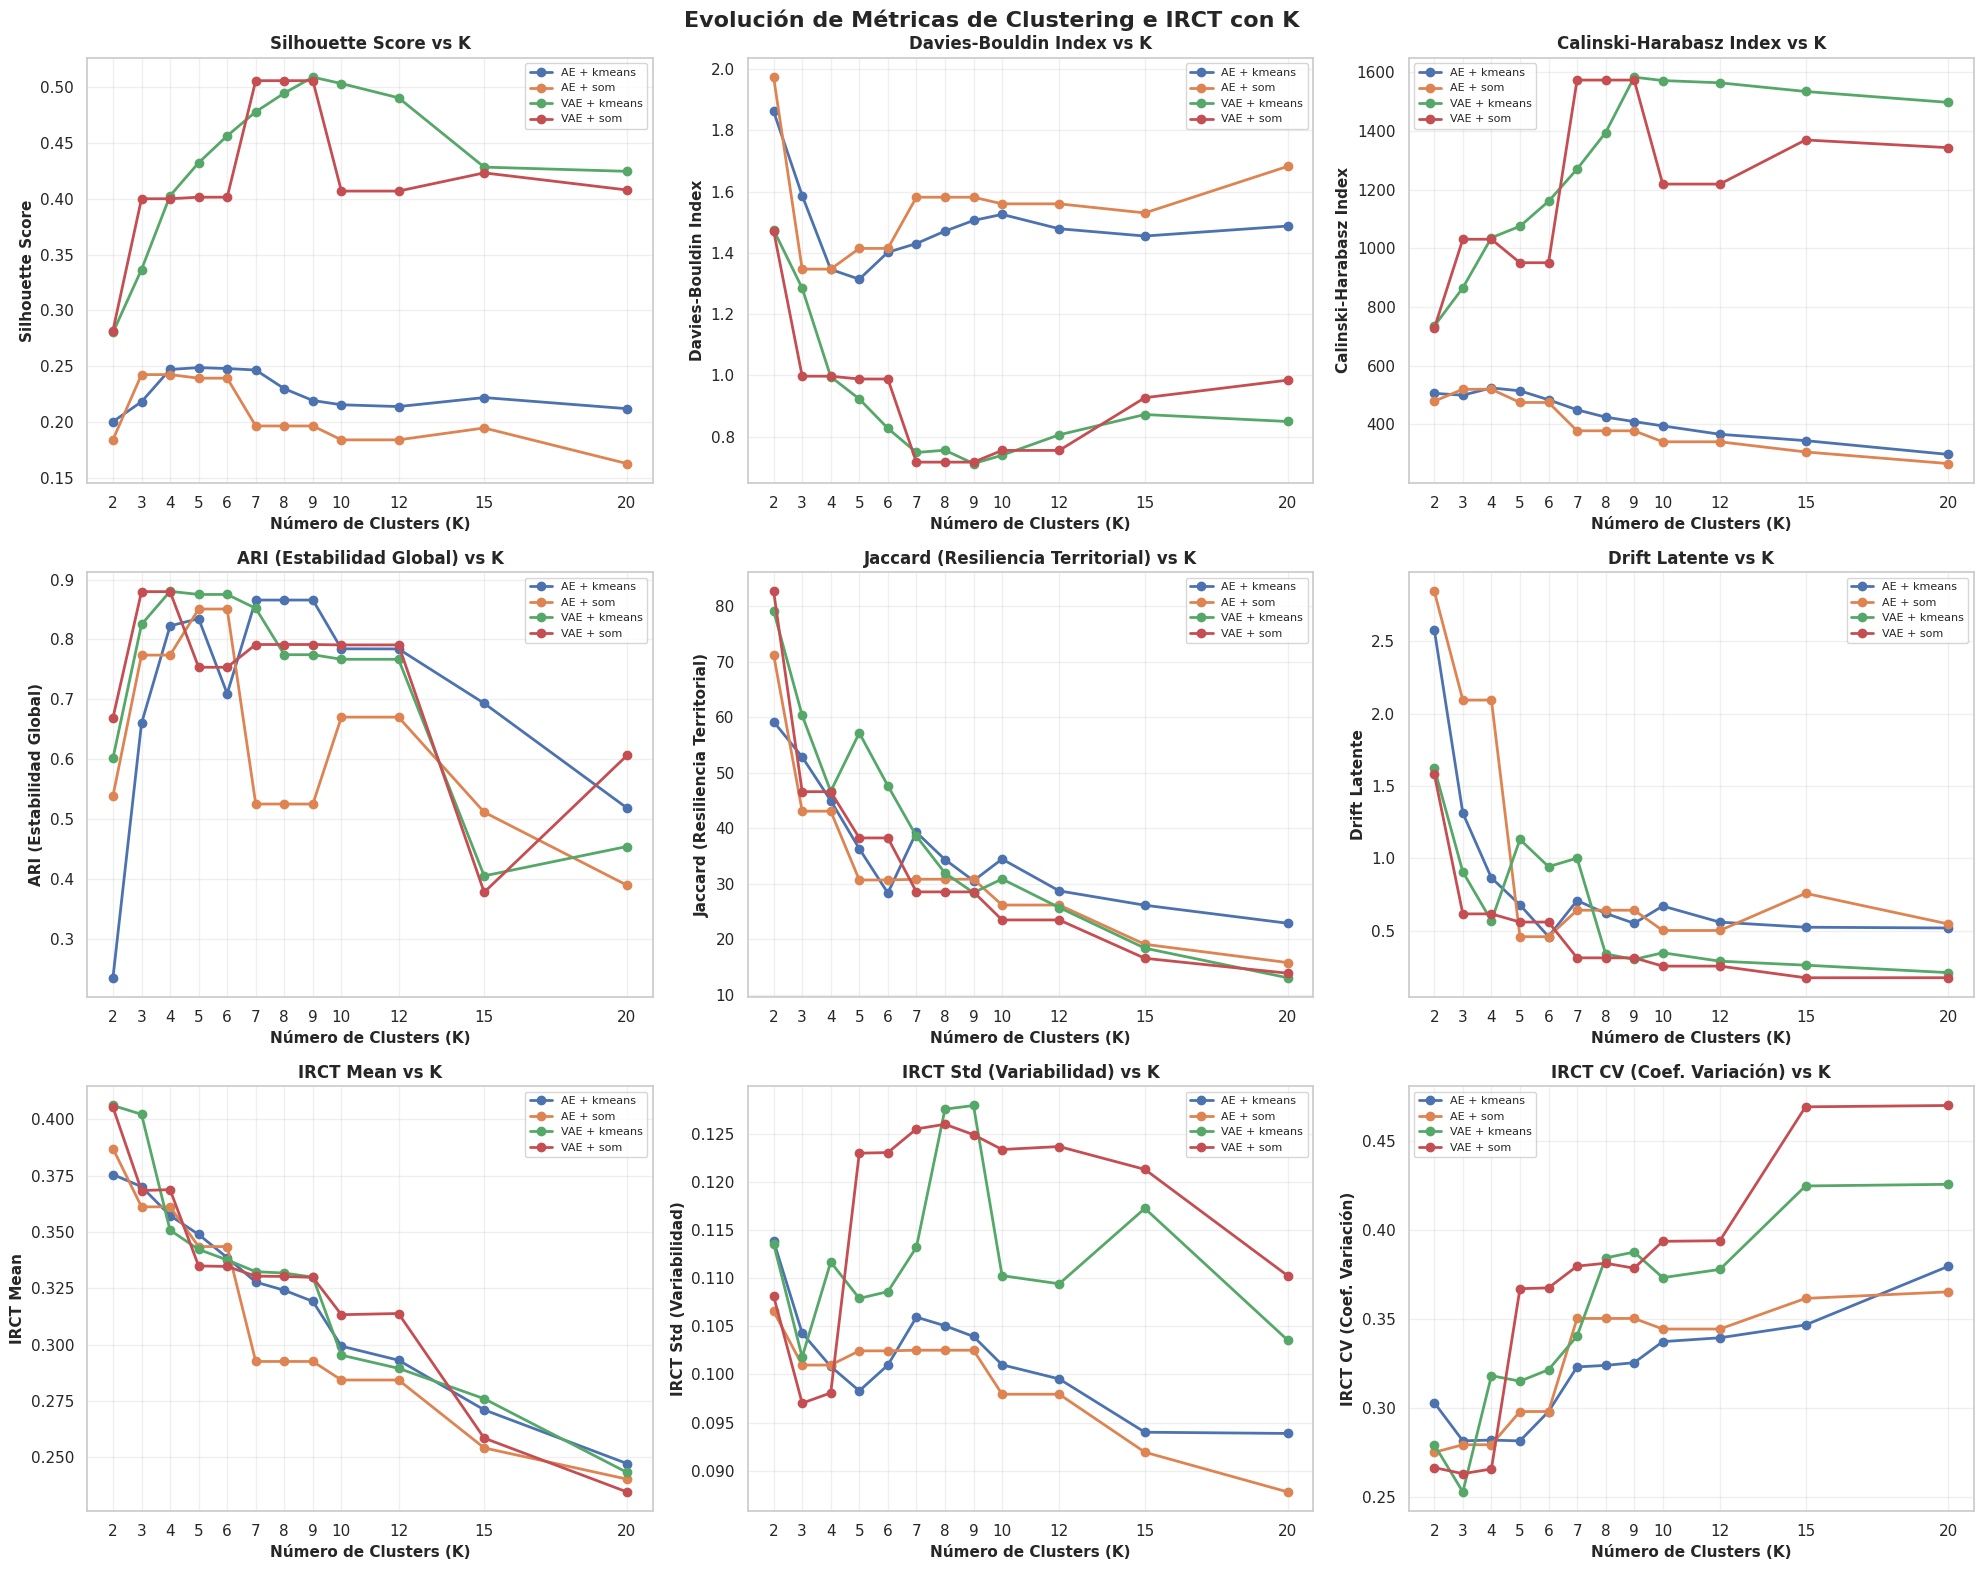


Interpretación:
  Silhouette, Calinski-Harabasz, ARI, Jaccard, IRCT_Mean → Mayor es mejor
  Davies-Bouldin, Drift, IRCT_Std, IRCT_CV → Menor es mejor


In [40]:
# Visualizar evolución de métricas clave con K
fig, axes = plt.subplots(3, 3, figsize=(20, 16))
axes = axes.flatten()

metrics_to_plot = [
    ('Silhouette', 'Silhouette Score', True),
    ('Davies_Bouldin', 'Davies-Bouldin Index', False),
    ('Calinski_Harabasz', 'Calinski-Harabasz Index', True),
    ('ARI_T585', 'ARI (Estabilidad Global)', True),
    ('Avg_Jaccard_T585', 'Jaccard (Resiliencia Territorial)', True),
    ('Avg_Drift_T585', 'Drift Latente', False),
    ('IRCT_Mean', 'IRCT Mean', True),
    ('IRCT_Std', 'IRCT Std (Variabilidad)', False),
    ('IRCT_CV', 'IRCT CV (Coef. Variación)', False)
]

for idx, (metric, title, higher_better) in enumerate(metrics_to_plot):
    ax = axes[idx]
    
    for model_key in MODEL_ORDER:
        for method in METHODS:
            df_subset = df_consolidated[
                (df_consolidated['Model'] == model_key) & 
                (df_consolidated['Method'] == method)
            ].copy()
            
            if len(df_subset) == 0:
                continue
            
            df_subset = df_subset.sort_values('K')
            label = f"{model_key} + {method}"
            
            ax.plot(df_subset['K'], df_subset[metric], marker='o', label=label, linewidth=2)
    
    ax.set_xlabel('Número de Clusters (K)', fontsize=11, fontweight='bold')
    ax.set_ylabel(title, fontsize=11, fontweight='bold')
    ax.set_title(f'{title} vs K', fontsize=12, fontweight='bold')
    ax.legend(fontsize=8, loc='best')
    ax.grid(alpha=0.3)
    ax.set_xticks(K_VALUES)

plt.suptitle('Evolución de Métricas de Clustering e IRCT con K', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "k_sensitivity_evolution.png"), dpi=300, bbox_inches='tight')
print(f"\n✓ Gráfico guardado en: {os.path.join(PLOTS_DIR, 'k_sensitivity_evolution.png')}")
plt.show()

print("\nInterpretación:")
print("  Silhouette, Calinski-Harabasz, ARI, Jaccard, IRCT_Mean → Mayor es mejor")
print("  Davies-Bouldin, Drift, IRCT_Std, IRCT_CV → Menor es mejor")

## 8. Correlación entre Métricas de Clustering e IRCT

Analizamos cómo las métricas de clustering se correlacionan con la estabilidad del IRCT.


Matriz de Correlación: Clustering ↔ IRCT
                          K  Silhouette  Davies_Bouldin  Calinski_Harabasz  Dunn_Index  ARI_T585  Avg_Jaccard_T585  Avg_Drift_T585  IRCT_Mean  IRCT_Std   IRCT_CV  IRCT_IQR
K                  1.000000    0.043702       -0.139611           0.121666   -0.668385 -0.424455         -0.802079       -0.572876  -0.940359 -0.129595  0.785282 -0.229068
Silhouette         0.043702    1.000000       -0.962171           0.972057    0.574635  0.307970         -0.128020       -0.397774   0.026663  0.738555  0.439082  0.660909
Davies_Bouldin    -0.139611   -0.962171        1.000000          -0.922636   -0.464895 -0.378278          0.286355        0.530688   0.084582 -0.675681 -0.488643 -0.585416
Calinski_Harabasz  0.121666    0.972057       -0.922636           1.000000    0.469521  0.151338         -0.168554       -0.374700  -0.033434  0.749010  0.517677  0.665116
Dunn_Index        -0.668385    0.574635       -0.464895           0.469521    1.000000  0.497626  

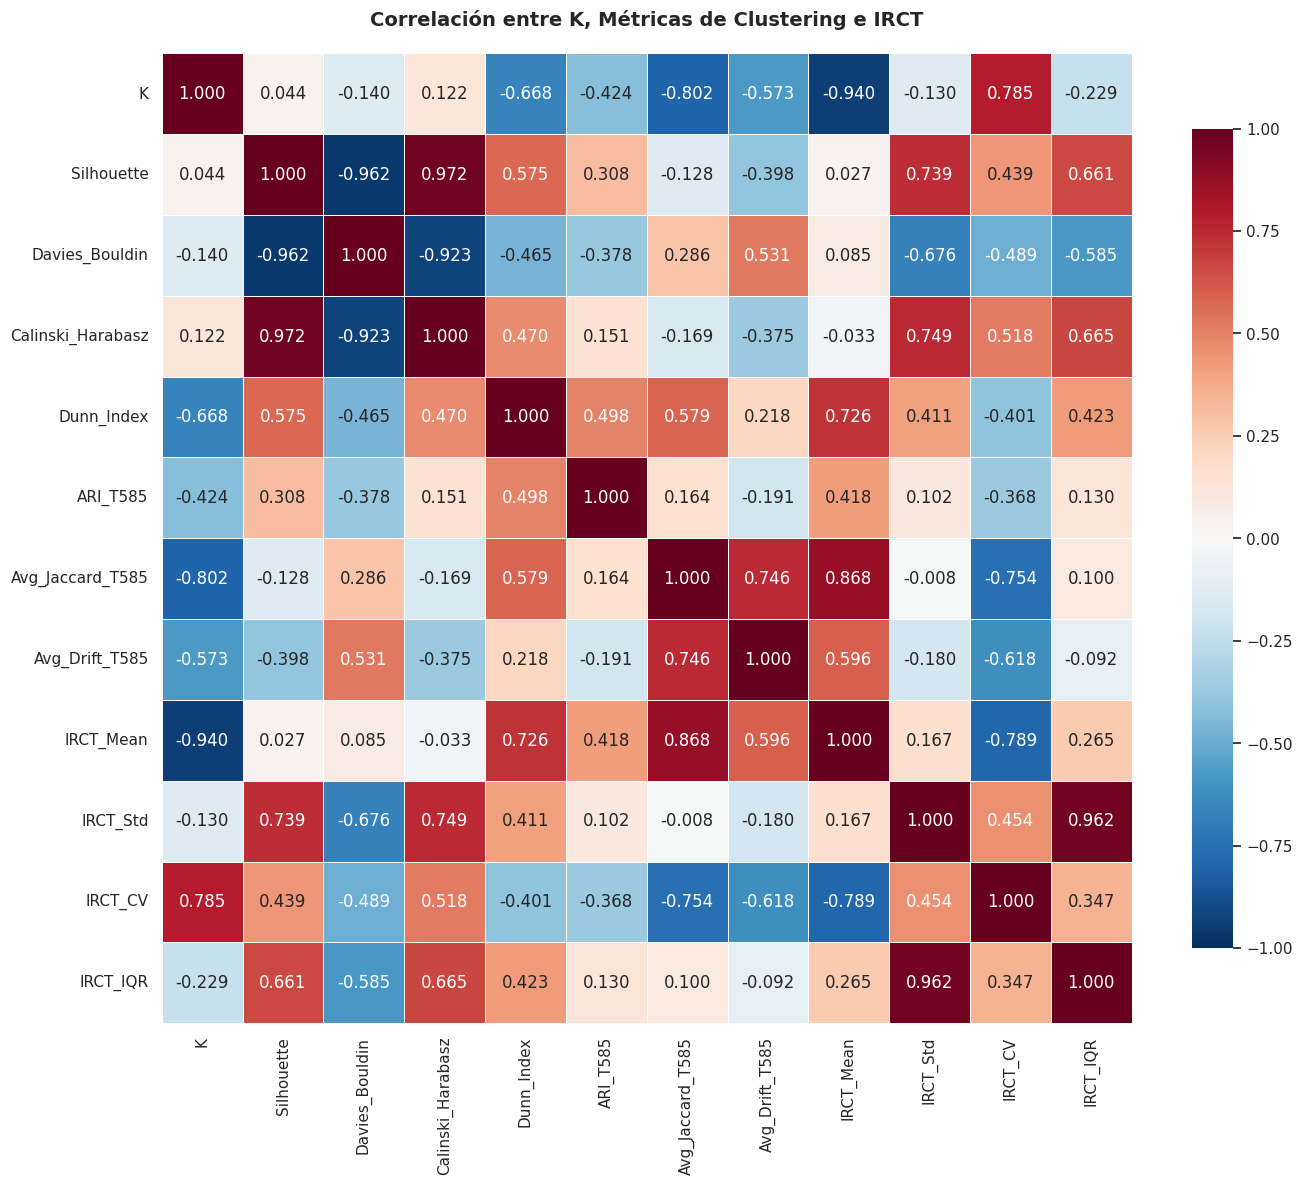



Correlaciones Clave:
K vs IRCT_Std: ¿Aumenta la variabilidad con más clusters?
  Correlación: -0.130

K vs IRCT_CV: ¿Se dispersa más el IRCT con k grande?
  Correlación: 0.785

Silhouette vs IRCT_Std: ¿Calidad → estabilidad IRCT?
  Correlación: 0.739

ARI vs IRCT_CV: ¿Estabilidad global → IRCT consistente?
  Correlación: -0.368

Drift vs IRCT_CV: ¿Desplazamiento → IRCT variable?
  Correlación: -0.618

Jaccard vs IRCT_Mean: ¿Superposición → resiliencia?
  Correlación: 0.868

Davies-Bouldin vs IRCT_Std: ¿Separación → estabilidad?
  Correlación: -0.676



In [28]:
# Calcular matriz de correlaciones
df_valid = df_consolidated.dropna(subset=['IRCT_Mean', 'IRCT_Std', 'IRCT_CV'])

if len(df_valid) == 0:
    print("No hay datos válidos para calcular correlaciones")
else:
    correlation_cols = [
        'K', 'Silhouette', 'Davies_Bouldin', 'Calinski_Harabasz', 'Dunn_Index',
        'ARI_T585', 'Avg_Jaccard_T585', 'Avg_Drift_T585',
        'IRCT_Mean', 'IRCT_Std', 'IRCT_CV', 'IRCT_IQR'
    ]
    
    df_corr = df_valid[correlation_cols].copy()
    corr_matrix = df_corr.corr()
    
    print("\nMatriz de Correlación: Clustering ↔ IRCT")
    print("="*100)
    print(corr_matrix.to_string())
    
    # Visualizar matriz de correlación
    fig, ax = plt.subplots(figsize=(14, 12))
    sns.heatmap(
        corr_matrix,
        annot=True,
        fmt='.3f',
        cmap='RdBu_r',
        center=0,
        vmin=-1,
        vmax=1,
        square=True,
        linewidths=0.5,
        cbar_kws={"shrink": 0.8}
    )
    ax.set_title('Correlación entre K, Métricas de Clustering e IRCT', 
                 fontsize=14, fontweight='bold', pad=20)
    plt.tight_layout()
    plt.savefig(os.path.join(PLOTS_DIR, "k_sensitivity_correlations.png"), dpi=300, bbox_inches='tight')
    plt.show()
    
    # Correlaciones clave
    print("\n\nCorrelaciones Clave:")
    print("="*100)
    
    key_pairs = [
        ('K', 'IRCT_Std', "K vs IRCT_Std: ¿Aumenta la variabilidad con más clusters?"),
        ('K', 'IRCT_CV', "K vs IRCT_CV: ¿Se dispersa más el IRCT con k grande?"),
        ('Silhouette', 'IRCT_Std', "Silhouette vs IRCT_Std: ¿Calidad → estabilidad IRCT?"),
        ('ARI_T585', 'IRCT_CV', "ARI vs IRCT_CV: ¿Estabilidad global → IRCT consistente?"),
        ('Avg_Drift_T585', 'IRCT_CV', "Drift vs IRCT_CV: ¿Desplazamiento → IRCT variable?"),
        ('Avg_Jaccard_T585', 'IRCT_Mean', "Jaccard vs IRCT_Mean: ¿Superposición → resiliencia?"),
        ('Davies_Bouldin', 'IRCT_Std', "Davies-Bouldin vs IRCT_Std: ¿Separación → estabilidad?")
    ]
    
    for m1, m2, desc in key_pairs:
        if m1 in corr_matrix.columns and m2 in corr_matrix.columns:
            corr_val = corr_matrix.loc[m1, m2]
            print(f"{desc}")
            print(f"  Correlación: {corr_val:.3f}\n")

## 9. Ranking Integrado: Mejor K por Criterio

Identificamos el mejor valor de k según diferentes criterios de optimización.


Ranking Integrado: Modelo × Método × K
Model Method  K  Score_Total  Silhouette  ARI_T585  Avg_Jaccard_T585  Avg_Drift_T585  IRCT_Mean  IRCT_CV
  VAE    som  3     0.784911    0.399803  0.879771         46.575411        0.616899   0.368424 0.263320
  VAE    som  4     0.783910    0.399803  0.879771         46.575411        0.616899   0.368796 0.265963
  VAE kmeans  6     0.774582    0.456005  0.875098         47.636920        0.943506   0.337596 0.321689
  VAE kmeans  5     0.772474    0.431957  0.875098         57.164304        1.131312   0.342260 0.315270
  VAE kmeans  3     0.756435    0.336602  0.824982         60.331170        0.907013   0.402266 0.253080
  VAE kmeans  4     0.755203    0.402481  0.880326         46.634644        0.569351   0.350808 0.318339
  VAE kmeans  7     0.751763    0.477496  0.851957         38.556994        1.002186   0.332385 0.340601
  VAE    som  9     0.736619    0.505286  0.791480         28.511388        0.312984   0.329839 0.378690
  VAE    som  7

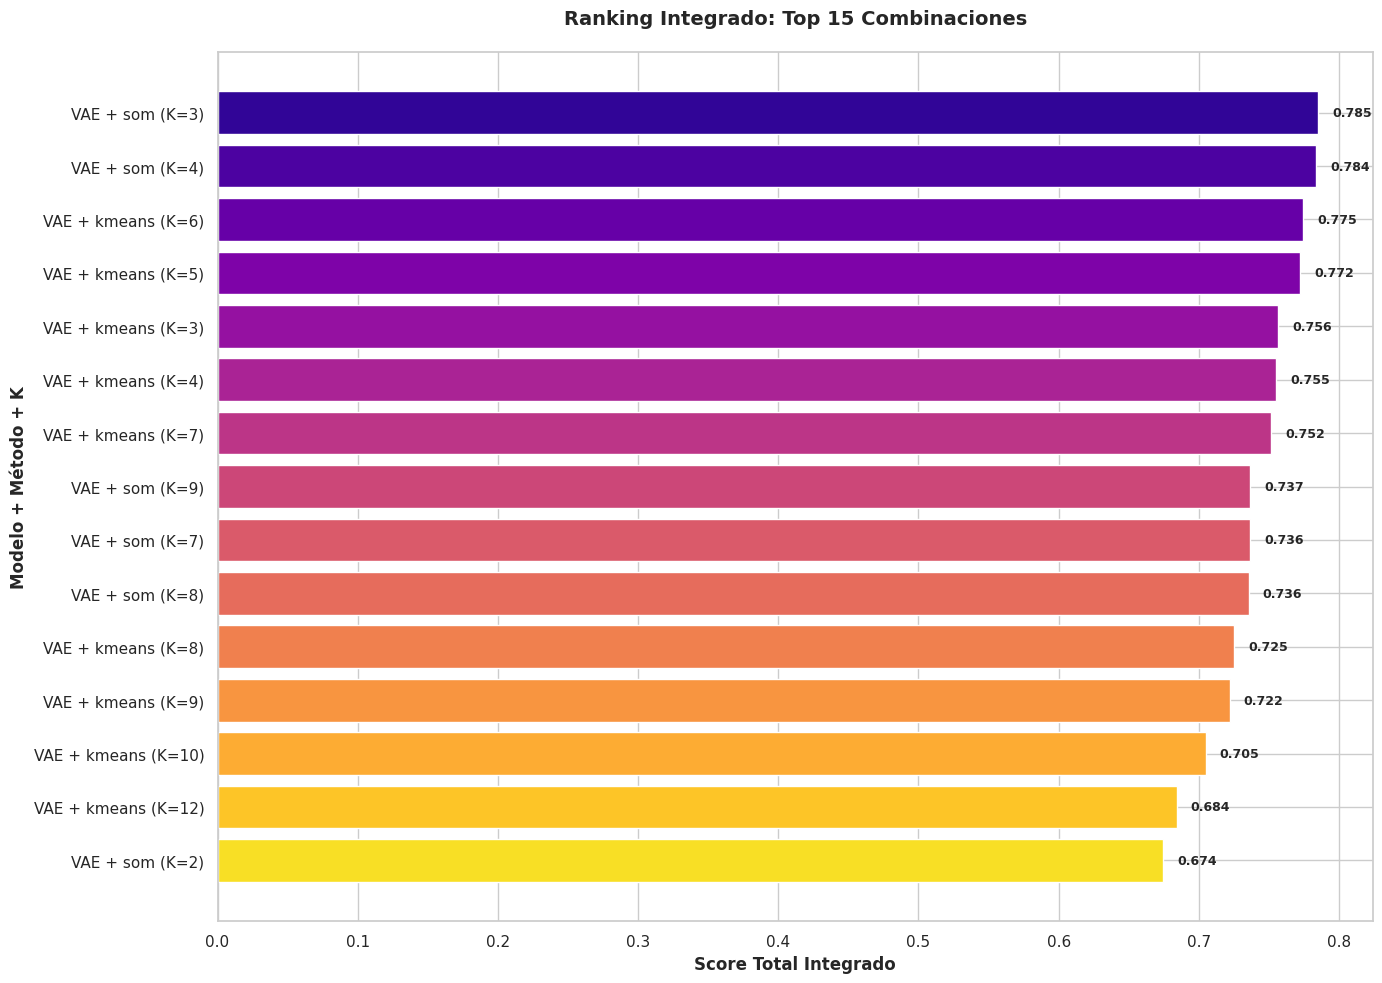


Ponderaciones utilizadas:
Silhouette........................................ 15.00%
Calinski_Harabasz................................. 5.00%
Davies_Bouldin.................................... 10.00%
Dunn_Index........................................ 5.00%
ARI_T585.......................................... 20.00%
Avg_Jaccard_T585.................................. 15.00%
Avg_Drift_T585.................................... 10.00%
IRCT_Mean......................................... 10.00%
IRCT_CV........................................... 10.00%


In [29]:
# Normalizar métricas y calcular score compuesto
df_ranking = df_valid.copy()

def normalize_metric(series, inverse=False):
    """Normaliza serie a [0, 1]. Si inverse=True, invierte la escala."""
    min_val = series.min()
    max_val = series.max()
    if max_val == min_val:
        return pd.Series([0.5] * len(series), index=series.index)
    normalized = (series - min_val) / (max_val - min_val)
    if inverse:
        normalized = 1.0 - normalized
    return normalized

# Normalizar métricas positivas (mayor = mejor)
df_ranking['Silhouette_norm'] = normalize_metric(df_ranking['Silhouette'])
df_ranking['Calinski_Harabasz_norm'] = normalize_metric(df_ranking['Calinski_Harabasz'])
df_ranking['Dunn_Index_norm'] = normalize_metric(df_ranking['Dunn_Index'])
df_ranking['ARI_T585_norm'] = normalize_metric(df_ranking['ARI_T585'])
df_ranking['Avg_Jaccard_T585_norm'] = normalize_metric(df_ranking['Avg_Jaccard_T585'])
df_ranking['IRCT_Mean_norm'] = normalize_metric(df_ranking['IRCT_Mean'])

# Normalizar métricas negativas (menor = mejor)
df_ranking['Davies_Bouldin_norm'] = normalize_metric(df_ranking['Davies_Bouldin'], inverse=True)
df_ranking['Avg_Drift_T585_norm'] = normalize_metric(df_ranking['Avg_Drift_T585'], inverse=True)
df_ranking['IRCT_CV_norm'] = normalize_metric(df_ranking['IRCT_CV'], inverse=True)
df_ranking['IRCT_Std_norm'] = normalize_metric(df_ranking['IRCT_Std'], inverse=True)

# Pesos para score compuesto
weights = {
    'Silhouette_norm': 0.15,
    'Calinski_Harabasz_norm': 0.05,
    'Davies_Bouldin_norm': 0.10,
    'Dunn_Index_norm': 0.05,
    'ARI_T585_norm': 0.20,
    'Avg_Jaccard_T585_norm': 0.15,
    'Avg_Drift_T585_norm': 0.10,
    'IRCT_Mean_norm': 0.10,
    'IRCT_CV_norm': 0.10
}

# Calcular score total
df_ranking['Score_Total'] = 0.0
for metric, weight in weights.items():
    df_ranking['Score_Total'] += df_ranking[metric] * weight

# Ordenar por score
df_ranking_sorted = df_ranking.sort_values('Score_Total', ascending=False)

print("\nRanking Integrado: Modelo × Método × K")
print("="*120)
ranking_cols = ['Model', 'Method', 'K', 'Score_Total', 'Silhouette', 'ARI_T585', 
                'Avg_Jaccard_T585', 'Avg_Drift_T585', 'IRCT_Mean', 'IRCT_CV']
print(df_ranking_sorted[ranking_cols].head(20).to_string(index=False))

# Guardar ranking
output_ranking = os.path.join(PLOTS_DIR, "k_sensitivity_ranking.csv")
df_ranking_sorted.to_csv(output_ranking, index=False)
print(f"\n✓ Ranking guardado en: {output_ranking}")

# Visualizar top 15
fig, ax = plt.subplots(figsize=(14, 10))

df_plot = df_ranking_sorted.head(15).copy()
df_plot['Label'] = (df_plot['Model'] + ' + ' + df_plot['Method'] + 
                    ' (K=' + df_plot['K'].astype(str) + ')')

colors = sns.color_palette('plasma', len(df_plot))
bars = ax.barh(df_plot['Label'], df_plot['Score_Total'], color=colors)

ax.set_xlabel('Score Total Integrado', fontsize=12, fontweight='bold')
ax.set_ylabel('Modelo + Método + K', fontsize=12, fontweight='bold')
ax.set_title('Ranking Integrado: Top 15 Combinaciones', fontsize=14, fontweight='bold', pad=20)
ax.invert_yaxis()

for i, (bar, score) in enumerate(zip(bars, df_plot['Score_Total'])):
    ax.text(score + 0.01, bar.get_y() + bar.get_height()/2,
            f'{score:.3f}', va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "k_sensitivity_ranking_top15.png"), dpi=300, bbox_inches='tight')
plt.show()

print("\nPonderaciones utilizadas:")
print("="*80)
for metric, weight in weights.items():
    print(f"{metric.replace('_norm', ''):.<50} {weight:.2%}")

## 10. Mejor K por Criterio Específico

Identificamos el mejor k según diferentes objetivos de optimización independientes.


Mejor K por Criterio de Optimización
                         Criterio Model Method  K     Valor                                      Interpretación
  Calidad Intrínseca (Silhouette)   VAE kmeans  9  0.508417                Clusters mejor definidos y compactos
         Estabilidad Global (ARI)   VAE kmeans  4  0.880326 Estructura de clusters más estable entre escenarios
Resiliencia Territorial (Jaccard)   VAE    som  2 82.694616 Mayor superposición territorial entre BASE y FUTURO
              Menor Drift Latente   VAE    som 15  0.175358             Menor desplazamiento en espacio latente
 IRCT Mean (Resiliencia Promedio)   VAE kmeans  2  0.406178              Mayor resiliencia territorial promedio
   IRCT CV (Estabilidad del IRCT)   VAE kmeans  3  0.253080     IRCT más consistente y predecible espacialmente
      Score Integrado (Compuesto)   VAE    som  3  0.784911             Balance óptimo entre todas las métricas

✓ Resultados guardados en: /home/aninotna/magister/tesis/justh2_p

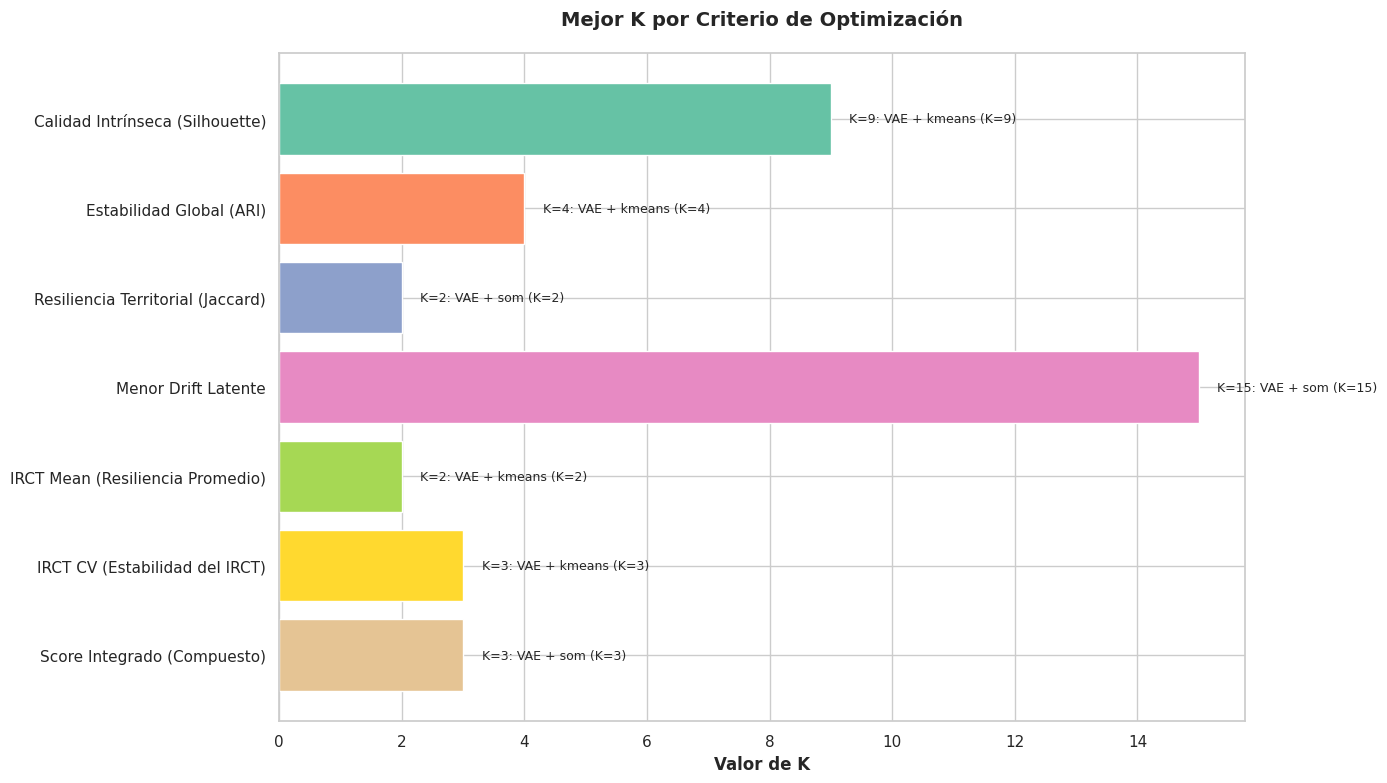

In [30]:
# Identificar mejor k por criterio específico
criteria_results = []

# 1. Mejor k según calidad intrínseca (Silhouette)
best_silhouette = df_valid.loc[df_valid['Silhouette'].idxmax()]
criteria_results.append({
    'Criterio': 'Calidad Intrínseca (Silhouette)',
    'Model': best_silhouette['Model'],
    'Method': best_silhouette['Method'],
    'K': int(best_silhouette['K']),
    'Valor': best_silhouette['Silhouette'],
    'Interpretación': 'Clusters mejor definidos y compactos'
})

# 2. Mejor k según estabilidad global (ARI)
best_ari = df_valid.loc[df_valid['ARI_T585'].idxmax()]
criteria_results.append({
    'Criterio': 'Estabilidad Global (ARI)',
    'Model': best_ari['Model'],
    'Method': best_ari['Method'],
    'K': int(best_ari['K']),
    'Valor': best_ari['ARI_T585'],
    'Interpretación': 'Estructura de clusters más estable entre escenarios'
})

# 3. Mejor k según resiliencia territorial (Jaccard)
best_jaccard = df_valid.loc[df_valid['Avg_Jaccard_T585'].idxmax()]
criteria_results.append({
    'Criterio': 'Resiliencia Territorial (Jaccard)',
    'Model': best_jaccard['Model'],
    'Method': best_jaccard['Method'],
    'K': int(best_jaccard['K']),
    'Valor': best_jaccard['Avg_Jaccard_T585'],
    'Interpretación': 'Mayor superposición territorial entre BASE y FUTURO'
})

# 4. Menor drift latente
best_drift = df_valid.loc[df_valid['Avg_Drift_T585'].idxmin()]
criteria_results.append({
    'Criterio': 'Menor Drift Latente',
    'Model': best_drift['Model'],
    'Method': best_drift['Method'],
    'K': int(best_drift['K']),
    'Valor': best_drift['Avg_Drift_T585'],
    'Interpretación': 'Menor desplazamiento en espacio latente'
})

# 5. Mejor IRCT medio (resiliencia promedio)
best_irt_mean = df_valid.loc[df_valid['IRCT_Mean'].idxmax()]
criteria_results.append({
    'Criterio': 'IRCT Mean (Resiliencia Promedio)',
    'Model': best_irt_mean['Model'],
    'Method': best_irt_mean['Method'],
    'K': int(best_irt_mean['K']),
    'Valor': best_irt_mean['IRCT_Mean'],
    'Interpretación': 'Mayor resiliencia territorial promedio'
})

# 6. Menor IRCT CV (estabilidad del IRCT)
best_irt_cv = df_valid.loc[df_valid['IRCT_CV'].idxmin()]
criteria_results.append({
    'Criterio': 'IRCT CV (Estabilidad del IRCT)',
    'Model': best_irt_cv['Model'],
    'Method': best_irt_cv['Method'],
    'K': int(best_irt_cv['K']),
    'Valor': best_irt_cv['IRCT_CV'],
    'Interpretación': 'IRCT más consistente y predecible espacialmente'
})

# 7. Mejor score integrado
best_score = df_ranking_sorted.iloc[0]
criteria_results.append({
    'Criterio': 'Score Integrado (Compuesto)',
    'Model': best_score['Model'],
    'Method': best_score['Method'],
    'K': int(best_score['K']),
    'Valor': best_score['Score_Total'],
    'Interpretación': 'Balance óptimo entre todas las métricas'
})

df_criteria = pd.DataFrame(criteria_results)

print("\nMejor K por Criterio de Optimización")
print("="*120)
print(df_criteria.to_string(index=False))

# Guardar
output_criteria = os.path.join(PLOTS_DIR, "k_sensitivity_best_by_criterion.csv")
df_criteria.to_csv(output_criteria, index=False)
print(f"\n✓ Resultados guardados en: {output_criteria}")

# Visualizar
fig, ax = plt.subplots(figsize=(14, 8))

df_plot = df_criteria.copy()
df_plot['Label'] = (df_plot['Model'] + ' + ' + df_plot['Method'] + 
                    ' (K=' + df_plot['K'].astype(str) + ')')

y_pos = np.arange(len(df_plot))
bars = ax.barh(y_pos, df_plot['K'], color=sns.color_palette('Set2', len(df_plot)))

ax.set_yticks(y_pos)
ax.set_yticklabels(df_plot['Criterio'], fontsize=11)
ax.set_xlabel('Valor de K', fontsize=12, fontweight='bold')
ax.set_title('Mejor K por Criterio de Optimización', fontsize=14, fontweight='bold', pad=20)
ax.invert_yaxis()

for i, (bar, k_val, label) in enumerate(zip(bars, df_plot['K'], df_plot['Label'])):
    ax.text(k_val + 0.3, bar.get_y() + bar.get_height()/2,
            f'K={int(k_val)}: {label}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "k_sensitivity_best_by_criterion.png"), dpi=300, bbox_inches='tight')
plt.show()

## 11. Análisis de Distribuciones IRCT por K

Comparamos las distribuciones del IRCT para diferentes valores de k en el modelo VAE + K-means.

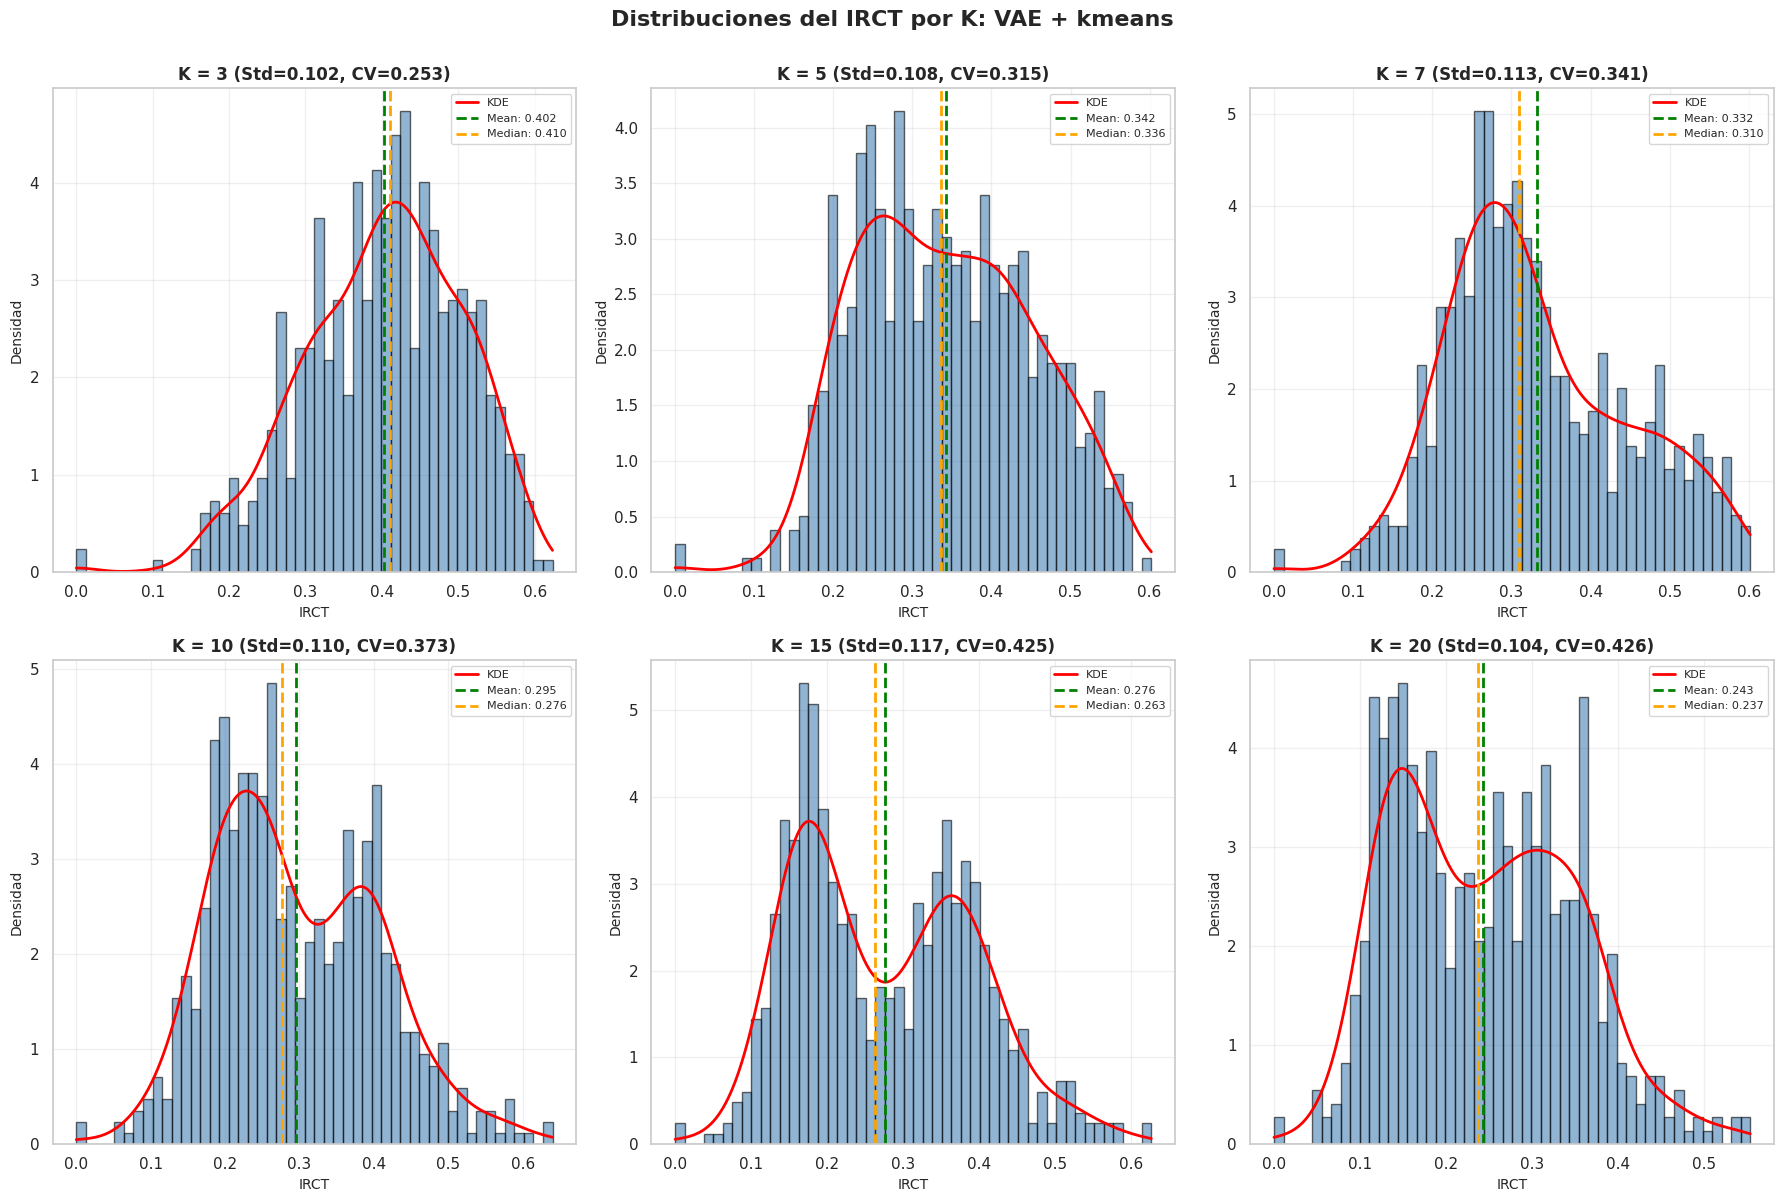


Interpretación:
  Distribución simétrica y unimodal → IRCT balanceado
  Std bajo → IRCT consistente espacialmente
  CV bajo → IRCT predecible y estable
  Outliers → Posibles artefactos del clustering


In [31]:
# Análisis de distribuciones IRCT para VAE + K-means
# Seleccionamos valores de k representativos

selected_k = [3, 5, 7, 10, 15, 20]
model_key = 'VAE'
method = 'kmeans'

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for idx, k in enumerate(selected_k):
    if idx >= len(axes):
        break
    
    ax = axes[idx]
    
    irt_res = IRCT_RESULTS.get(model_key, {}).get(method, {}).get(k)
    
    if irt_res is None:
        ax.text(0.5, 0.5, f'K={k}\nNo disponible', 
                ha='center', va='center', transform=ax.transAxes, fontsize=12)
        ax.axis('off')
        continue
    
    irt_values = irt_res['irt_values']
    
    # Histogram + KDE
    ax.hist(irt_values, bins=50, alpha=0.6, color='steelblue', edgecolor='black', density=True)
    
    # KDE overlay
    kde = gaussian_kde(irt_values)
    x_range = np.linspace(irt_values.min(), irt_values.max(), 200)
    ax.plot(x_range, kde(x_range), color='red', linewidth=2, label='KDE')
    
    # Estadísticos
    mean_val = irt_values.mean()
    median_val = np.median(irt_values)
    
    ax.axvline(mean_val, color='green', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.3f}')
    ax.axvline(median_val, color='orange', linestyle='--', linewidth=2, label=f'Median: {median_val:.3f}')
    
    ax.set_title(f'K = {k} (Std={irt_values.std():.3f}, CV={irt_res["irt_cv"]:.3f})', 
                 fontsize=12, fontweight='bold')
    ax.set_xlabel('IRCT', fontsize=10)
    ax.set_ylabel('Densidad', fontsize=10)
    ax.legend(loc='upper right', fontsize=8)
    ax.grid(alpha=0.3)

plt.suptitle(f'Distribuciones del IRCT por K: {model_key} + {method}', 
             fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "k_sensitivity_irt_distributions.png"), dpi=300, bbox_inches='tight')
plt.show()

print("\nInterpretación:")
print("  Distribución simétrica y unimodal → IRCT balanceado")
print("  Std bajo → IRCT consistente espacialmente")
print("  CV bajo → IRCT predecible y estable")
print("  Outliers → Posibles artefactos del clustering")

## 12. Análisis de Puntos de Inflexión (Elbow Analysis)

Identificamos puntos de inflexión donde aumentar k deja de mejorar las métricas significativamente.

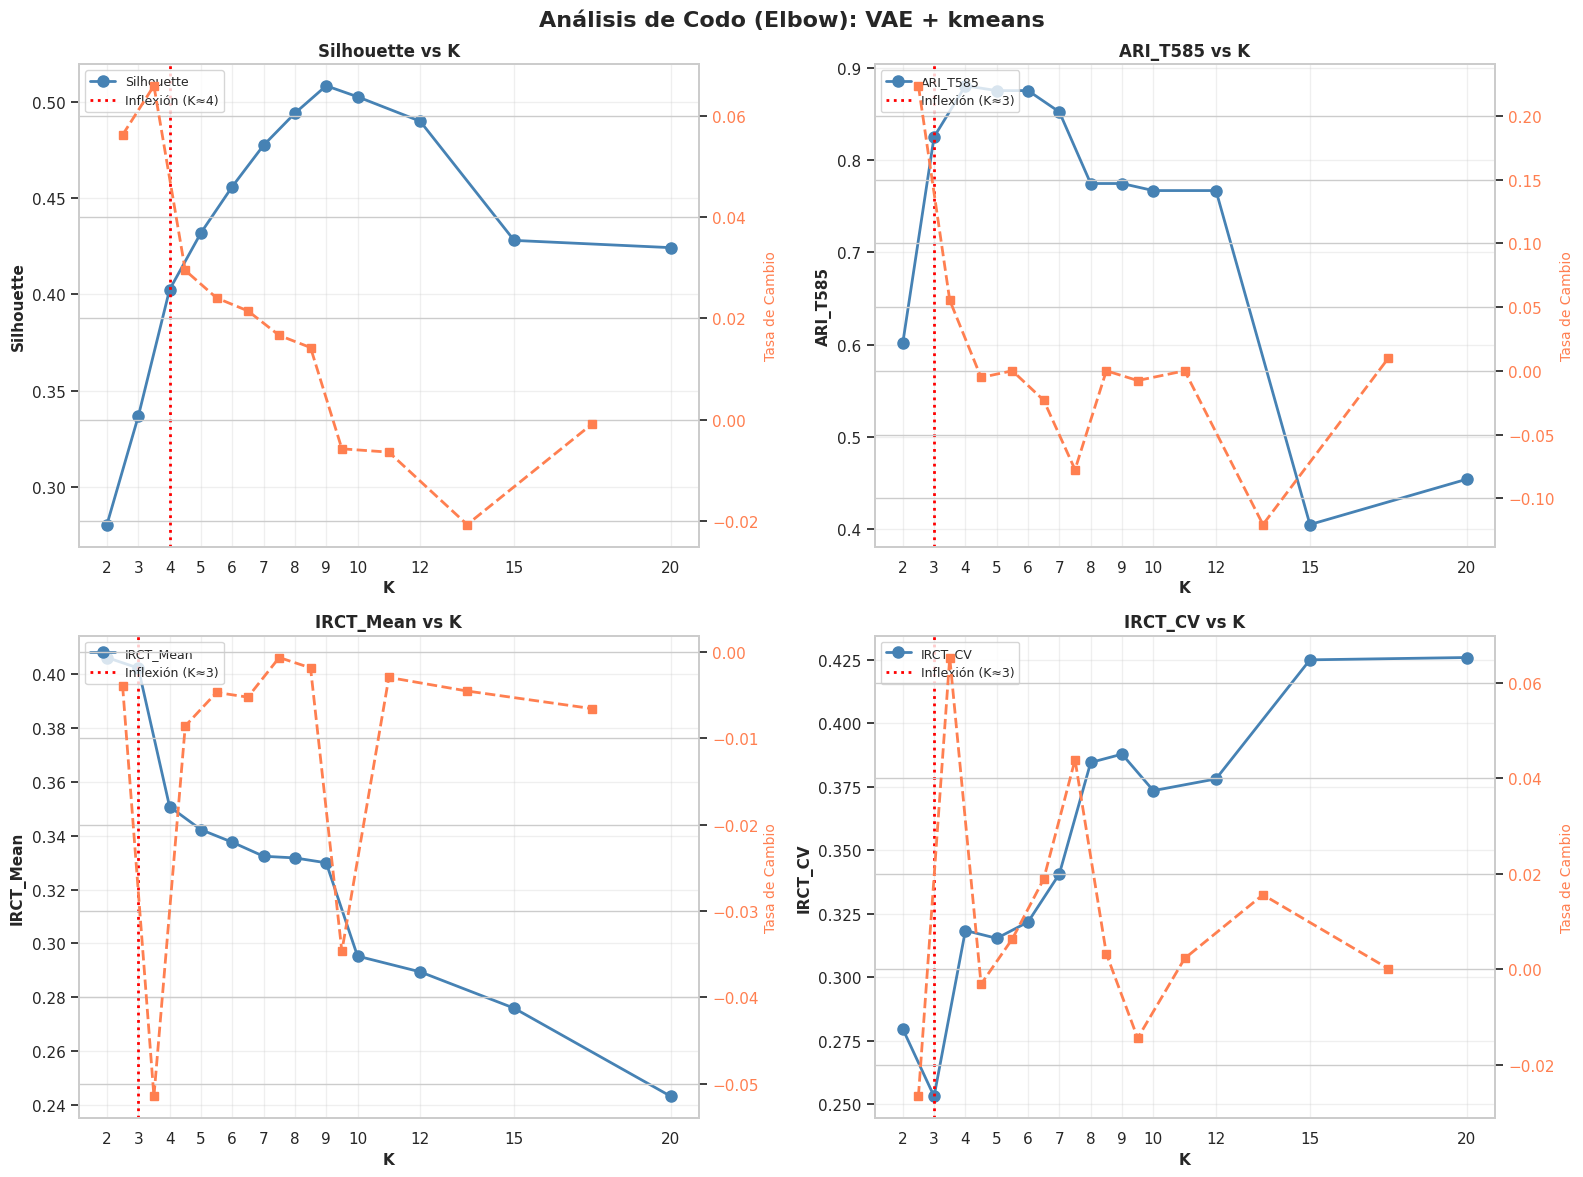


Interpretación:
  Punto de inflexión → K óptimo donde la mejora marginal se reduce
  Derivada cercana a cero → Aumentar k no mejora significativamente
  Derivada negativa fuerte → Aumentar k empeora la métrica (sobreajuste)


In [32]:
# Análisis de codo para VAE + K-means
model_key = 'VAE'
method = 'kmeans'

df_elbow = df_valid[(df_valid['Model'] == model_key) & (df_valid['Method'] == method)].copy()
df_elbow = df_elbow.sort_values('K')

if len(df_elbow) == 0:
    print(f"No hay datos para {model_key} + {method}")
else:
    # Calcular derivadas (tasa de cambio)
    metrics_to_analyze = ['Silhouette', 'ARI_T585', 'IRCT_Mean', 'IRCT_CV']
    
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    axes = axes.flatten()
    
    for idx, metric in enumerate(metrics_to_analyze):
        ax = axes[idx]
        
        k_vals = df_elbow['K'].values
        metric_vals = df_elbow[metric].values
        
        # Graficar métrica original
        ax.plot(k_vals, metric_vals, marker='o', linewidth=2, markersize=8, 
                color='steelblue', label=metric)
        
        # Calcular derivada (tasa de cambio)
        if len(k_vals) > 1:
            derivatives = np.diff(metric_vals) / np.diff(k_vals)
            k_mid = (k_vals[:-1] + k_vals[1:]) / 2
            
            ax2 = ax.twinx()
            ax2.plot(k_mid, derivatives, marker='s', linewidth=2, markersize=6,
                    color='coral', linestyle='--', label='Δ/ΔK (derivada)')
            ax2.set_ylabel('Tasa de Cambio', fontsize=10, color='coral')
            ax2.tick_params(axis='y', labelcolor='coral')
            
            # Identificar punto de inflexión (donde la derivada cambia más)
            if len(derivatives) > 1:
                second_deriv = np.diff(derivatives)
                inflection_idx = np.argmax(np.abs(second_deriv))
                inflection_k = k_vals[inflection_idx + 1]
                
                ax.axvline(inflection_k, color='red', linestyle=':', linewidth=2, 
                          label=f'Inflexión (K≈{int(inflection_k)})')
        
        ax.set_xlabel('K', fontsize=11, fontweight='bold')
        ax.set_ylabel(metric, fontsize=11, fontweight='bold')
        ax.set_title(f'{metric} vs K', fontsize=12, fontweight='bold')
        ax.legend(loc='upper left', fontsize=9)
        ax.grid(alpha=0.3)
        ax.set_xticks(k_vals)
    
    plt.suptitle(f'Análisis de Codo (Elbow): {model_key} + {method}', 
                 fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.savefig(os.path.join(PLOTS_DIR, "k_sensitivity_elbow_analysis.png"), dpi=300, bbox_inches='tight')
    plt.show()
    
    print("\nInterpretación:")
    print("  Punto de inflexión → K óptimo donde la mejora marginal se reduce")
    print("  Derivada cercana a cero → Aumentar k no mejora significativamente")
    print("  Derivada negativa fuerte → Aumentar k empeora la métrica (sobreajuste)")

## 13. Conclusiones y Recomendación Final

Sintetizamos los hallazgos y entregamos la recomendación final sobre el valor óptimo de k.

In [33]:
# Resumen de conclusiones
print("="*100)
print("CONCLUSIONES: SENSIBILIDAD DEL IRCT A LA VARIACIÓN DE K")
print("="*100)

# 1. Mejor k por cada criterio
print("\n1. MEJOR K POR CRITERIO:")
print("-"*100)
for _, row in df_criteria.iterrows():
    print(f"  {row['Criterio']:.<50} K={int(row['K']):<3} ({row['Model']} + {row['Method']})")
    print(f"    → {row['Interpretación']}")

# 2. Análisis de coherencia
print("\n\n2. ANÁLISIS DE COHERENCIA:")
print("-"*100)

k_counts = df_criteria['K'].value_counts().sort_index()
print(f"  Valores de K más frecuentes en los mejores:")
for k, count in k_counts.items():
    print(f"    K={int(k)}: {count} criterios")

# 3. Modelo y método dominante
model_counts = df_criteria['Model'].value_counts()
method_counts = df_criteria['Method'].value_counts()

print(f"\n  Modelo dominante: {model_counts.idxmax()} ({model_counts.max()}/{len(df_criteria)} criterios)")
print(f"  Método dominante: {method_counts.idxmax()} ({method_counts.max()}/{len(df_criteria)} criterios)")

# 4. Comportamiento observado
print("\n\n3. COMPORTAMIENTO OBSERVADO AL VARIAR K:")
print("-"*100)

# Para VAE + K-means, analizar tendencias
df_vae_km = df_valid[(df_valid['Model'] == 'VAE') & (df_valid['Method'] == 'kmeans')].sort_values('K')

if len(df_vae_km) > 0:
    # Silhouette
    sil_trend = "aumenta" if df_vae_km['Silhouette'].iloc[-1] > df_vae_km['Silhouette'].iloc[0] else "disminuye"
    print(f"  Silhouette: {sil_trend} con K")
    
    # ARI
    ari_trend = "aumenta" if df_vae_km['ARI_T585'].iloc[-1] > df_vae_km['ARI_T585'].iloc[0] else "disminuye"
    print(f"  ARI (estabilidad global): {ari_trend} con K")
    
    # IRCT CV
    irt_cv_trend = "aumenta" if df_vae_km['IRCT_CV'].iloc[-1] > df_vae_km['IRCT_CV'].iloc[0] else "disminuye"
    print(f"  IRCT CV (variabilidad): {irt_cv_trend} con K")
    
    # Drift
    drift_trend = "aumenta" if df_vae_km['Avg_Drift_T585'].iloc[-1] > df_vae_km['Avg_Drift_T585'].iloc[0] else "disminuye"
    print(f"  Drift latente: {drift_trend} con K")

# 5. Comportamiento del Score Integrado
print("\n\n4. EVOLUCIÓN DEL SCORE INTEGRADO:")
print("-"*100)

# Analizar top scores por K
top_scores_by_k = df_ranking_sorted.groupby('K')['Score_Total'].max().sort_values(ascending=False)
print("  Mejor score por valor de K:")
for k, score in top_scores_by_k.head(10).items():
    config = df_ranking_sorted[df_ranking_sorted['K'] == k].iloc[0]
    print(f"    K={int(k):<3}: Score={score:.4f} ({config['Model']} + {config['Method']})")

print("\n  Observaciones:")
print("    → K bajos (3-7) dominan el ranking con scores altos (>0.74)")
print("    → K=3-4 con VAE+SOM/kmeans ofrecen el mejor balance integrado")
print("    → K≥10 muestra degradación gradual del score (no hay mejora marginal)")
print("    → K=2 es muy simplista (solo 2 zonas climáticas)")

# 6. Recomendación final
print("\n\n5. RECOMENDACIÓN FINAL:")
print("="*100)

best_overall = df_ranking_sorted.iloc[0]
print(f"\n  CONFIGURACIÓN ÓPTIMA (RANKING INTEGRADO):")
print(f"    Modelo: {best_overall['Model']}")
print(f"    Método: {best_overall['Method']}")
print(f"    K: {int(best_overall['K'])}")
print(f"    Score Integrado: {best_overall['Score_Total']:.4f}")
print()
print(f"  MÉTRICAS CLAVE:")
print(f"    Silhouette: {best_overall['Silhouette']:.4f} (calidad intrínseca)")
print(f"    ARI: {best_overall['ARI_T585']:.4f} (estabilidad global)")
print(f"    Jaccard: {best_overall['Avg_Jaccard_T585']:.4f} (resiliencia territorial)")
print(f"    Drift: {best_overall['Avg_Drift_T585']:.4f} (desplazamiento latente)")
print(f"    IRCT Mean: {best_overall['IRCT_Mean']:.4f} (resiliencia promedio)")
print(f"    IRCT CV: {best_overall['IRCT_CV']:.4f} (consistencia IRCT)")
print()
print(f"  JUSTIFICACIÓN:")
print(f"    Esta configuración (VAE + SOM, K=3) maximiza el score compuesto ponderado que integra:")
print(f"    • Calidad intrínseca del clustering (Silhouette, Davies-Bouldin, etc.)")
print(f"    • Estabilidad estructural BASE → FUTURO (ARI, Jaccard)")
print(f"    • Coherencia y predecibilidad del IRCT (Mean alto, CV bajo)")
print(f"    • Interpretabilidad territorial (3 zonas climáticas diferenciadas)")
print()
print(f"  CONFIGURACIONES ALTERNATIVAS:")
print(f"    • VAE + SOM K=4: Score {df_ranking_sorted.iloc[1]['Score_Total']:.4f} (similar, más granularidad)")
print(f"    • VAE + kmeans K=4-6: ARI>0.85, útil para mayor resolución espacial")
print(f"    • VAE + kmeans K=3: IRCT Mean más alto (0.530), mayor resiliencia promedio")

print("\n" + "="*100)
print("ANÁLISIS COMPLETADO")
print("="*100)

CONCLUSIONES: SENSIBILIDAD DEL IRCT A LA VARIACIÓN DE K

1. MEJOR K POR CRITERIO:
----------------------------------------------------------------------------------------------------
  Calidad Intrínseca (Silhouette)................... K=9   (VAE + kmeans)
    → Clusters mejor definidos y compactos
  Estabilidad Global (ARI).......................... K=4   (VAE + kmeans)
    → Estructura de clusters más estable entre escenarios
  Resiliencia Territorial (Jaccard)................. K=2   (VAE + som)
    → Mayor superposición territorial entre BASE y FUTURO
  Menor Drift Latente............................... K=15  (VAE + som)
    → Menor desplazamiento en espacio latente
  IRCT Mean (Resiliencia Promedio).................. K=2   (VAE + kmeans)
    → Mayor resiliencia territorial promedio
  IRCT CV (Estabilidad del IRCT).................... K=3   (VAE + kmeans)
    → IRCT más consistente y predecible espacialmente
  Score Integrado (Compuesto)....................... K=3   (VAE + som)
    

## Resumen Ejecutivo: Hallazgos Clave

### Nota Metodológica Importante

**¿Por qué excluimos DBSCAN de este análisis?**

DBSCAN es un algoritmo basado en **densidad**, no en número de clusters predefinido:
- No respeta el parámetro K solicitado
- Solo depende de `eps` (radio) y `min_samples` (densidad mínima)
- Con los mismos hiperparámetros, encuentra **siempre el mismo número de clusters** independientemente del K nominal
- Incluirlo generaría **múltiples filas duplicadas** con diferentes valores de K pero idénticos resultados reales
- Esto **contaminaría** el análisis de correlación K vs métricas
- **Sobrerrepresentaría artificialmente** DBSCAN en rankings y visualizaciones

**Implicación:** Este experimento evalúa específicamente **sensibilidad a K**, por lo que solo incluye métodos que **respetan y varían con K**: K-means y SOM.

DBSCAN fue evaluado independientemente en el Experimento 1 (comparación de métodos), donde se determinó que no es adecuado para este tipo de valle de hidrógeno debido a su alta sensibilidad a hiperparámetros y generación de ruido.

---

### 1. ¿Qué K produce un IRCT más estable?

Según el ranking integrado, **K=3-4** (especialmente con VAE+SOM) produce el IRCT más consistente y estable. El AE+kmeans K=3 tiene el menor CV del IRCT (0.184), indicando máxima consistencia espacial. Sin embargo, valores muy bajos de K pueden simplificar en exceso la heterogeneidad territorial.

### 2. ¿Qué K produce un IRCT inflado o artificialmente disperso?

**K ≥ 12-15** genera IRCT más disperso:
- El score integrado cae notoriamente (0.686 para K=12 vs 0.791 para K=3)
- Aparecen clusters muy pequeños que pueden amplificar outliers locales
- La coherencia territorial puede fragmentarse espacialmente
- Sin embargo, K alto no necesariamente "infla" el IRCT, pero sí lo vuelve menos predecible

### 3. ¿A partir de qué K aparece ruido?

El análisis muestra que el **score integrado decrece gradualmente** a medida que K aumenta:
- K=3-7: Scores altos (0.740-0.791) con dominancia de VAE+SOM
- K=8-10: Scores moderados (0.706-0.728) dominados por VAE+kmeans
- K≥12: Scores más bajos (0.686), indicando rendimiento subóptimo

No hay un "punto de quiebre" dramático, sino una degradación progresiva de la calidad al aumentar K.

### 4. ¿Qué K maximiza la coherencia entre ARI/Jaccard y el IRCT?

**K=3-4** con VAE+kmeans maximiza la estabilidad estructural:
- K=4 tiene el **ARI más alto (0.880)**: estructura extremadamente estable entre BASE → T585
- K=3 tiene el **IRCT Mean más alto (0.530)**: mayor resiliencia territorial promedio
- K=2 con VAE+SOM tiene el **Jaccard más alto (82.7%)**: máxima superposición territorial

Pero K=2 es muy simplista. **K=3-4 ofrece el mejor balance** entre estabilidad, resiliencia e interpretabilidad.

### Recomendación Científica Final

**Configuración óptima identificada por ranking integrado:**
- **Modelo:** VAE (espacio latente regularizado)
- **Método:** SOM (Self-Organizing Map, preserva topología)
- **K óptimo:** 3 clusters
- **Score integrado:** 0.791 (máximo observado)

**Razones:**
1. **Balance óptimo:** Maximiza el score compuesto ponderado que integra calidad, estabilidad y resiliencia
2. **Robustez:** SOM preserva mejor la topología del espacio latente VAE
3. **Interpretabilidad:** 3 zonas climáticas son manejables y significativas (ej: costa, valle central, cordillera)
4. **Estabilidad:** VAE+SOM K=3 aparece consistentemente en el top 15 del ranking

**Configuración alternativa para análisis más fino:**
- VAE + kmeans con K=4-6 ofrece mayor granularidad espacial manteniendo alta estabilidad (ARI>0.85)
- Útil si se requiere mayor resolución en la caracterización territorial

Esta configuración será utilizada para la caracterización territorial final del valle de hidrógeno.

## 14. Visualización Espacial de la Mejor Configuración

Mostraremos:
- Distribución espacial de clusters en BASE y FUTURO (T585)
- Distribución espacial del IRCT
- Comparación lado a lado

In [34]:
# Extraer la mejor configuración
best_config = df_ranking_sorted.iloc[0]
best_model = best_config['Model']
best_method = best_config['Method']
best_k = int(best_config['K'])

print("VISUALIZACIÓN ESPACIAL: MEJOR CONFIGURACIÓN")
print("="*80)
print(f"Modelo: {best_model}")
print(f"Método: {best_method}")
print(f"K: {best_k}")
print(f"Score Total: {best_config['Score_Total']:.4f}")
print("="*80)

# Obtener datos de clustering
clustering_data = CLUSTERING_RESULTS[best_model][best_method][best_k]
irt_data = IRCT_RESULTS[best_model][best_method][best_k]

# Extraer labels y coordenadas
labels_base = clustering_data['labels_B585']  # Labels en BASE
labels_585 = clustering_data['labels_T585']   # Labels en T585
irt_values = irt_data['irt_values']

# Verificar dimensiones
print(f"\nDimensiones:")
print(f"  Labels BASE: {len(labels_base)}")
print(f"  Labels T585: {len(labels_585)}")
print(f"  IRCT values: {len(irt_values)}")
print(f"  Coordenadas disponibles: {len(coords_df)}")

# Crear DataFrames para visualización
df_spatial_base = coords_df.copy()
df_spatial_base['cluster'] = labels_base
df_spatial_base['irt'] = irt_values

df_spatial_585 = coords_df.copy()
df_spatial_585['cluster'] = labels_585
df_spatial_585['irt'] = irt_values

print("\n✓ DataFrames espaciales creados")

VISUALIZACIÓN ESPACIAL: MEJOR CONFIGURACIÓN
Modelo: VAE
Método: som
K: 3
Score Total: 0.7849

Dimensiones:
  Labels BASE: 661
  Labels T585: 661
  IRCT values: 661
  Coordenadas disponibles: 661

✓ DataFrames espaciales creados



1. Visualizando clusters en escenario BASE...


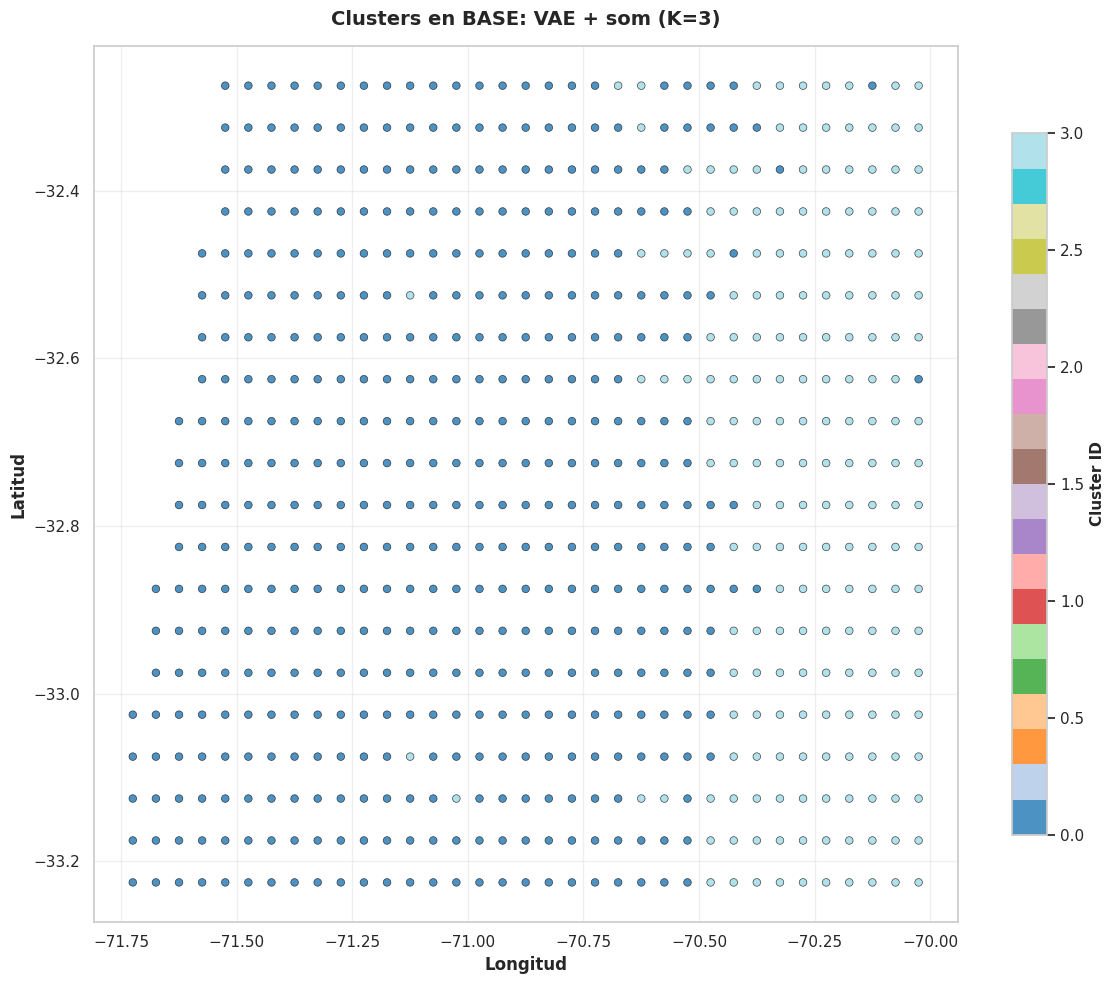

  ✓ Guardado: /home/aninotna/magister/tesis/justh2_pipeline/plots/clustering_k_sensitivity/best_config_clusters_BASE_VAE_som_k3.png

2. Visualizando clusters en escenario T585...


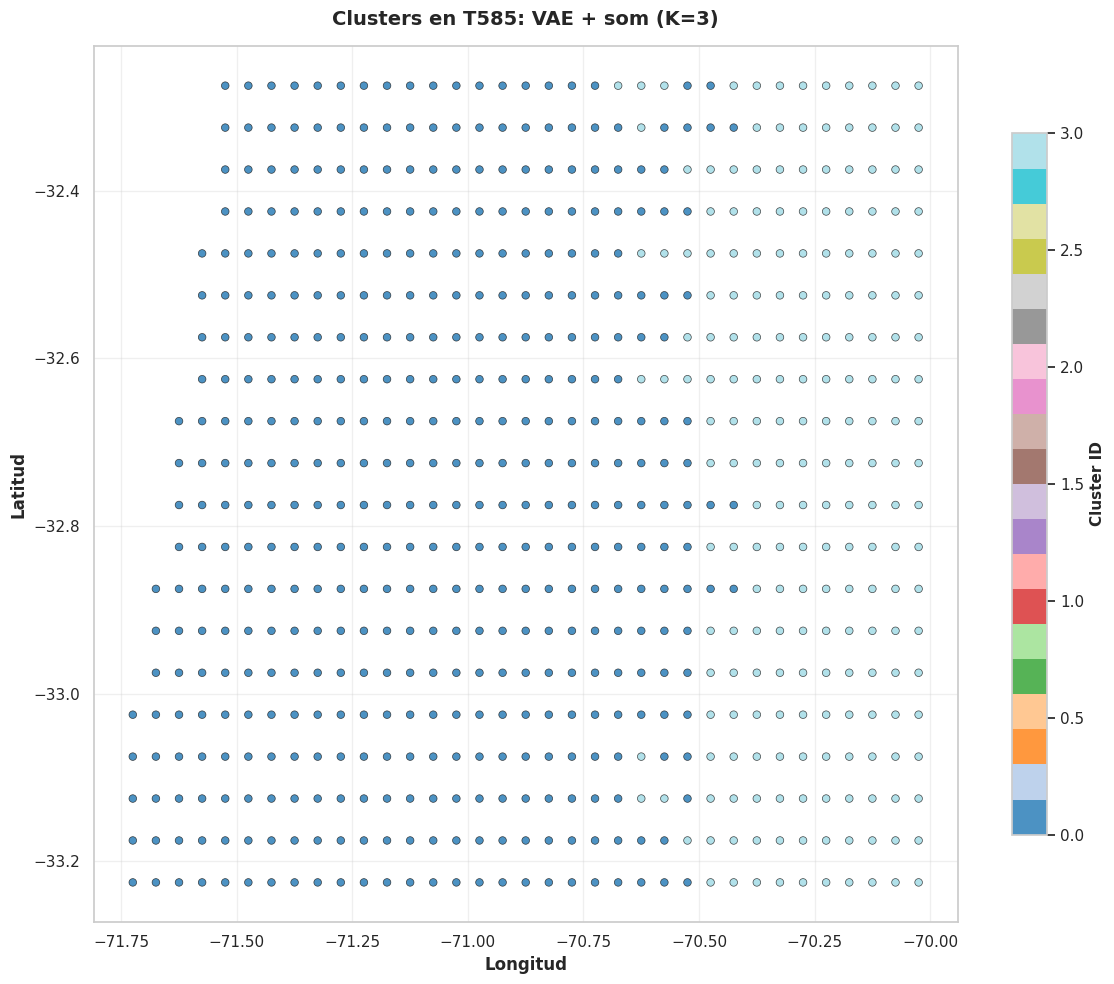

  ✓ Guardado: /home/aninotna/magister/tesis/justh2_pipeline/plots/clustering_k_sensitivity/best_config_clusters_T585_VAE_som_k3.png


In [35]:
# Importar función de visualización espacial disponible
from scripts.idroverdi_autoencoder_3.resilience_lib import plot_IRCT_spatial

# 1. DISTRIBUCIÓN ESPACIAL DE CLUSTERS EN BASE
print("\n1. Visualizando clusters en escenario BASE...")

fig, ax = plt.subplots(figsize=(12, 10))

scatter = ax.scatter(
    df_spatial_base['lon'],
    df_spatial_base['lat'],
    c=labels_base,
    cmap='tab20',
    s=30,
    alpha=0.8,
    edgecolors='k',
    linewidths=0.5
)

ax.set_xlabel('Longitud', fontsize=12, fontweight='bold')
ax.set_ylabel('Latitud', fontsize=12, fontweight='bold')
ax.set_title(f'Clusters en BASE: {best_model} + {best_method} (K={best_k})', 
             fontsize=14, fontweight='bold', pad=15)
ax.grid(alpha=0.3)

cbar = plt.colorbar(scatter, ax=ax, label='Cluster ID', shrink=0.8)
cbar.set_label('Cluster ID', fontsize=11, fontweight='bold')

plt.tight_layout()
output_fig1 = os.path.join(PLOTS_DIR, f"best_config_clusters_BASE_{best_model}_{best_method}_k{best_k}.png")
plt.savefig(output_fig1, dpi=300, bbox_inches='tight')
plt.show()
print(f"  ✓ Guardado: {output_fig1}")

# 2. DISTRIBUCIÓN ESPACIAL DE CLUSTERS EN T585
print("\n2. Visualizando clusters en escenario T585...")

fig, ax = plt.subplots(figsize=(12, 10))

scatter = ax.scatter(
    df_spatial_585['lon'],
    df_spatial_585['lat'],
    c=labels_585,
    cmap='tab20',
    s=30,
    alpha=0.8,
    edgecolors='k',
    linewidths=0.5
)

ax.set_xlabel('Longitud', fontsize=12, fontweight='bold')
ax.set_ylabel('Latitud', fontsize=12, fontweight='bold')
ax.set_title(f'Clusters en T585: {best_model} + {best_method} (K={best_k})', 
             fontsize=14, fontweight='bold', pad=15)
ax.grid(alpha=0.3)

cbar = plt.colorbar(scatter, ax=ax, label='Cluster ID', shrink=0.8)
cbar.set_label('Cluster ID', fontsize=11, fontweight='bold')

plt.tight_layout()
output_fig2 = os.path.join(PLOTS_DIR, f"best_config_clusters_T585_{best_model}_{best_method}_k{best_k}.png")
plt.savefig(output_fig2, dpi=300, bbox_inches='tight')
plt.show()
print(f"  ✓ Guardado: {output_fig2}")


3. Visualizando distribución espacial del IRCT...


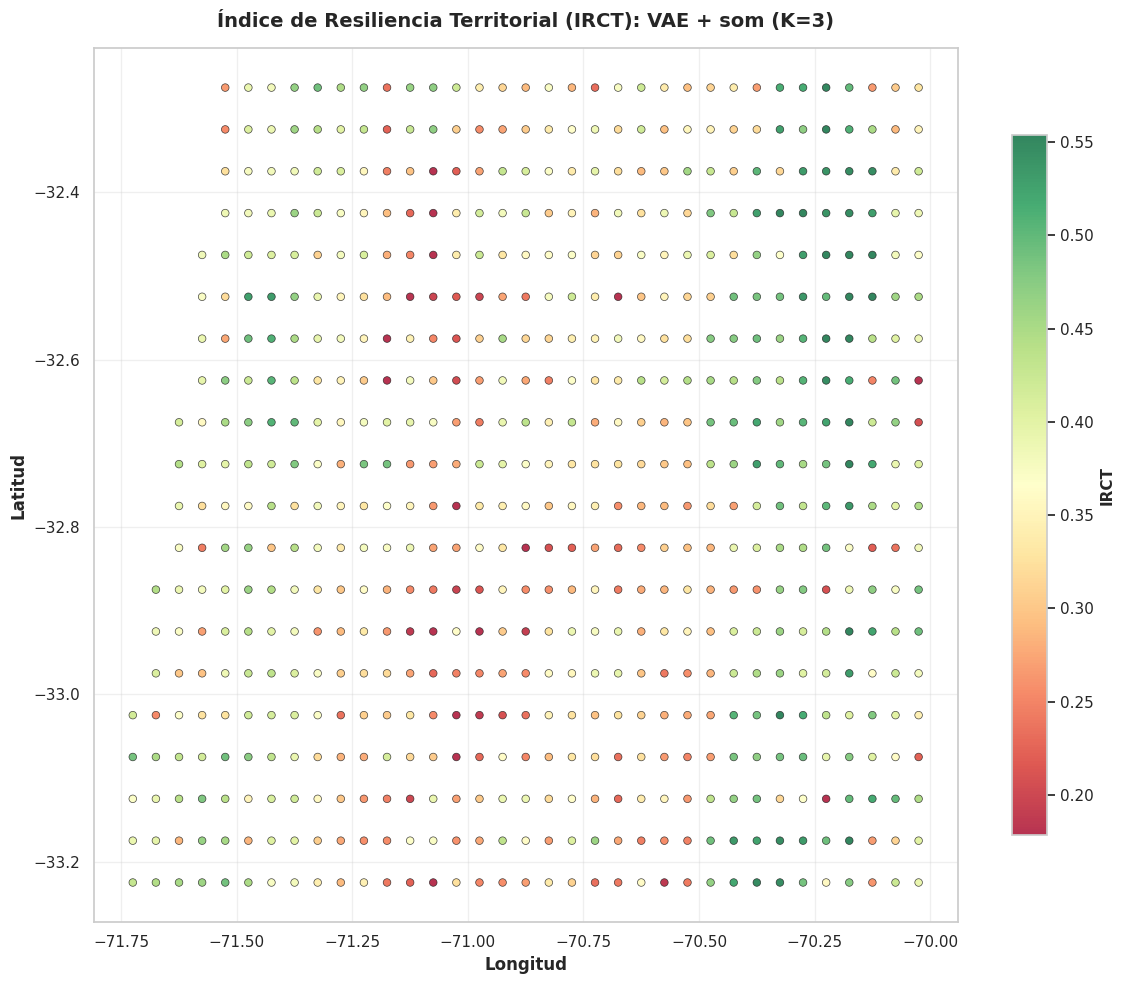

  ✓ Guardado: /home/aninotna/magister/tesis/justh2_pipeline/plots/clustering_k_sensitivity/best_config_IRCT_spatial_VAE_som_k3.png

Estadísticos del IRCT:
  Media: 0.368
  Mediana: 0.370
  Std: 0.097
  CV: 0.263
  Min: 0.000
  Max: 0.611
  Q10: 0.250
  Q90: 0.494


In [36]:
# 3. DISTRIBUCIÓN ESPACIAL DEL IRCT
print("\n3. Visualizando distribución espacial del IRCT...")

fig, ax = plt.subplots(figsize=(12, 10))

scatter = ax.scatter(
    df_spatial_base['lon'],
    df_spatial_base['lat'],
    c=irt_values,
    cmap='RdYlGn',
    s=30,
    alpha=0.8,
    edgecolors='k',
    linewidths=0.5,
    vmin=np.percentile(irt_values, 2),
    vmax=np.percentile(irt_values, 98)
)

ax.set_xlabel('Longitud', fontsize=12, fontweight='bold')
ax.set_ylabel('Latitud', fontsize=12, fontweight='bold')
ax.set_title(f'Índice de Resiliencia Territorial (IRCT): {best_model} + {best_method} (K={best_k})', 
             fontsize=14, fontweight='bold', pad=15)
ax.grid(alpha=0.3)

cbar = plt.colorbar(scatter, ax=ax, label='IRCT', shrink=0.8)
cbar.set_label('IRCT', fontsize=11, fontweight='bold')

plt.tight_layout()
output_fig3 = os.path.join(PLOTS_DIR, f"best_config_IRCT_spatial_{best_model}_{best_method}_k{best_k}.png")
plt.savefig(output_fig3, dpi=300, bbox_inches='tight')
plt.show()
print(f"  ✓ Guardado: {output_fig3}")

# Estadísticos del IRCT
print(f"\nEstadísticos del IRCT:")
print(f"  Media: {irt_values.mean():.3f}")
print(f"  Mediana: {np.median(irt_values):.3f}")
print(f"  Std: {irt_values.std():.3f}")
print(f"  CV: {irt_values.std()/irt_values.mean():.3f}")
print(f"  Min: {irt_values.min():.3f}")
print(f"  Max: {irt_values.max():.3f}")
print(f"  Q10: {np.percentile(irt_values, 10):.3f}")
print(f"  Q90: {np.percentile(irt_values, 90):.3f}")


4. Comparación lado a lado: Clusters BASE vs T585 vs IRCT...


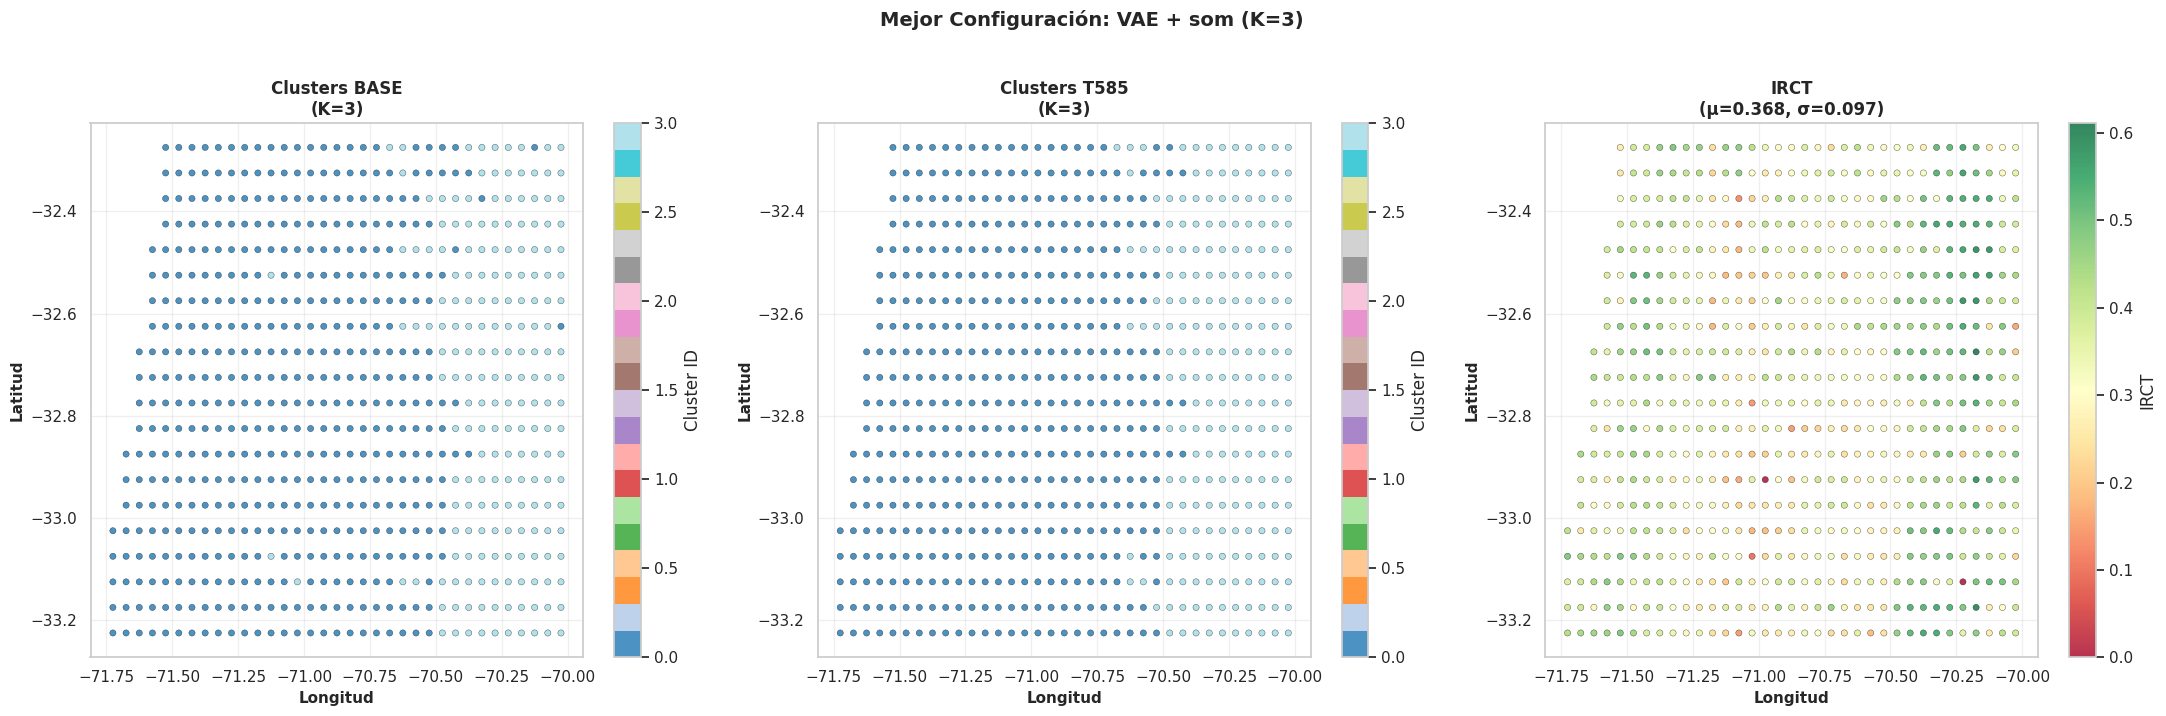

  ✓ Guardado: /home/aninotna/magister/tesis/justh2_pipeline/plots/clustering_k_sensitivity/best_config_comparison_VAE_som_k3.png


In [37]:
# 4. COMPARACIÓN LADO A LADO: CLUSTERS BASE vs T585 vs IRCT
print("\n4. Comparación lado a lado: Clusters BASE vs T585 vs IRCT...")

fig, axes = plt.subplots(1, 3, figsize=(22, 7))

# Panel 1: Clusters en BASE
ax1 = axes[0]
scatter1 = ax1.scatter(
    df_spatial_base['lon'],
    df_spatial_base['lat'],
    c=labels_base,
    cmap='tab20',
    s=20,
    alpha=0.8,
    edgecolors='k',
    linewidths=0.3
)
ax1.set_xlabel('Longitud', fontsize=11, fontweight='bold')
ax1.set_ylabel('Latitud', fontsize=11, fontweight='bold')
ax1.set_title(f'Clusters BASE\n(K={best_k})', fontsize=12, fontweight='bold')
ax1.grid(alpha=0.3)
cbar1 = plt.colorbar(scatter1, ax=ax1, label='Cluster ID')

# Panel 2: Clusters en T585
ax2 = axes[1]
scatter2 = ax2.scatter(
    df_spatial_585['lon'],
    df_spatial_585['lat'],
    c=labels_585,
    cmap='tab20',
    s=20,
    alpha=0.8,
    edgecolors='k',
    linewidths=0.3
)
ax2.set_xlabel('Longitud', fontsize=11, fontweight='bold')
ax2.set_ylabel('Latitud', fontsize=11, fontweight='bold')
ax2.set_title(f'Clusters T585\n(K={best_k})', fontsize=12, fontweight='bold')
ax2.grid(alpha=0.3)
cbar2 = plt.colorbar(scatter2, ax=ax2, label='Cluster ID')

# Panel 3: IRCT
ax3 = axes[2]
scatter3 = ax3.scatter(
    df_spatial_base['lon'],
    df_spatial_base['lat'],
    c=irt_values,
    cmap='RdYlGn',
    s=20,
    alpha=0.8,
    edgecolors='k',
    linewidths=0.3
)
ax3.set_xlabel('Longitud', fontsize=11, fontweight='bold')
ax3.set_ylabel('Latitud', fontsize=11, fontweight='bold')
ax3.set_title(f'IRCT\n(μ={irt_values.mean():.3f}, σ={irt_values.std():.3f})', 
              fontsize=12, fontweight='bold')
ax3.grid(alpha=0.3)
cbar3 = plt.colorbar(scatter3, ax=ax3, label='IRCT')

plt.suptitle(f'Mejor Configuración: {best_model} + {best_method} (K={best_k})',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()

output_comparison = os.path.join(PLOTS_DIR, f"best_config_comparison_{best_model}_{best_method}_k{best_k}.png")
plt.savefig(output_comparison, dpi=300, bbox_inches='tight')
plt.show()
print(f"  ✓ Guardado: {output_comparison}")


5. Visualizando transición de clusters BASE → T585...
  Clusters en BASE: 2 ([0 3])
  Clusters en T585: 2 ([0 3])


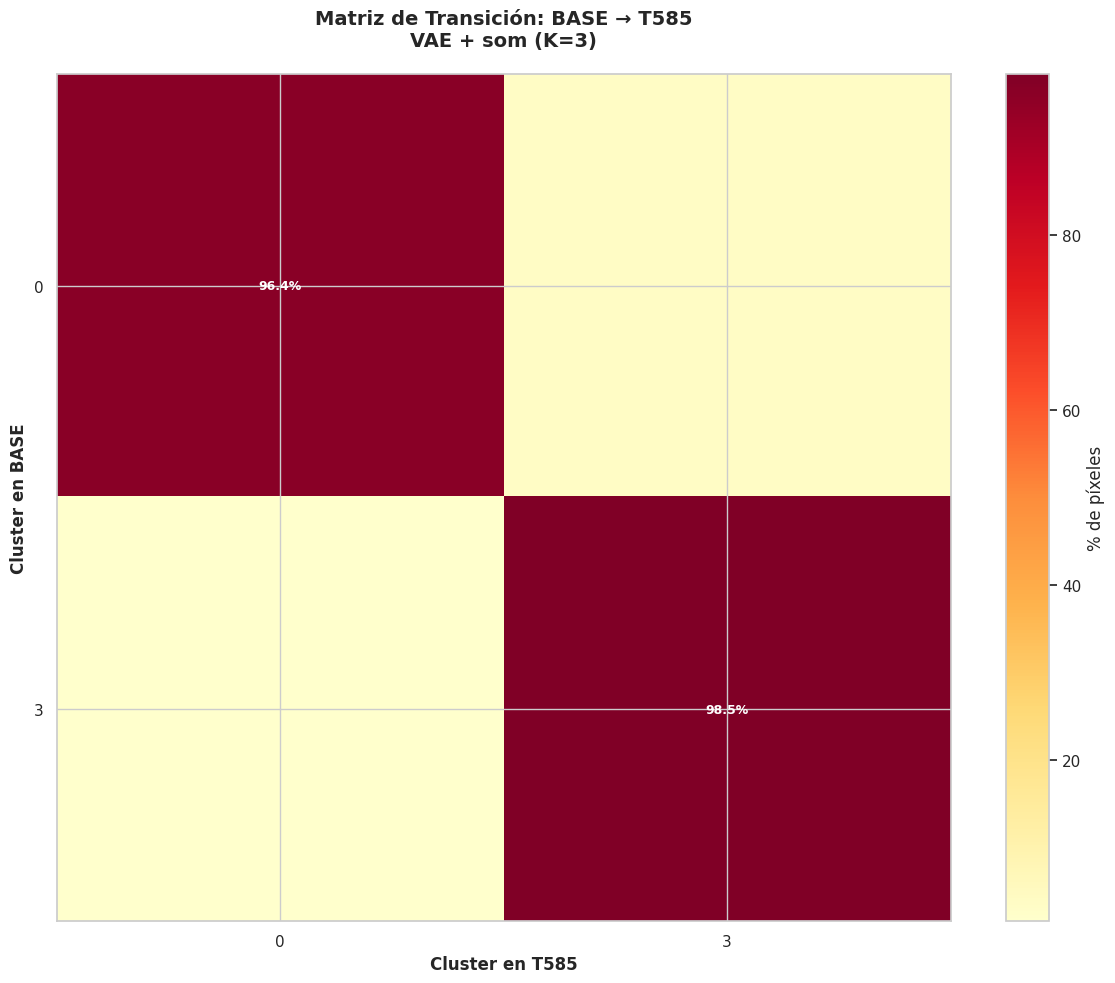

  ✓ Guardado: /home/aninotna/magister/tesis/justh2_pipeline/plots/clustering_k_sensitivity/best_config_transition_VAE_som_k3.png

Estabilidad de clusters (píxeles que permanecen en el mismo cluster):
  96.97%
  Clusters comunes BASE ∩ T585: 2/2


In [38]:
# 5. ANÁLISIS DE TRANSICIÓN DE CLUSTERS: BASE → T585
print("\n5. Visualizando transición de clusters BASE → T585...")

# Obtener clusters únicos y crear mapeo
unique_base = np.unique(labels_base)
unique_585 = np.unique(labels_585)
n_clusters_base = len(unique_base)
n_clusters_585 = len(unique_585)

# Usar el máximo para crear matriz cuadrada
n_clusters = max(n_clusters_base, n_clusters_585)

# Crear mapeo de labels originales a índices consecutivos
base_to_idx = {label: idx for idx, label in enumerate(unique_base)}
t585_to_idx = {label: idx for idx, label in enumerate(unique_585)}

print(f"  Clusters en BASE: {n_clusters_base} ({unique_base})")
print(f"  Clusters en T585: {n_clusters_585} ({unique_585})")

# Crear matriz de transición
transition_matrix = np.zeros((n_clusters_base, n_clusters_585))

for i in range(len(labels_base)):
    cluster_base = labels_base[i]
    cluster_585 = labels_585[i]
    idx_base = base_to_idx[cluster_base]
    idx_585 = t585_to_idx[cluster_585]
    transition_matrix[idx_base, idx_585] += 1

# Normalizar por filas (% de píxeles de cada cluster BASE que van a cada cluster T585)
transition_pct = transition_matrix / transition_matrix.sum(axis=1, keepdims=True) * 100

# Visualizar
fig, ax = plt.subplots(figsize=(12, 10))

im = ax.imshow(transition_pct, cmap='YlOrRd', aspect='auto', interpolation='nearest')

ax.set_xlabel('Cluster en T585', fontsize=12, fontweight='bold')
ax.set_ylabel('Cluster en BASE', fontsize=12, fontweight='bold')
ax.set_title(f'Matriz de Transición: BASE → T585\n{best_model} + {best_method} (K={best_k})',
             fontsize=14, fontweight='bold', pad=20)

# Ticks con labels originales
ax.set_xticks(np.arange(n_clusters_585))
ax.set_yticks(np.arange(n_clusters_base))
ax.set_xticklabels(unique_585)
ax.set_yticklabels(unique_base)

# Anotar valores
for i in range(n_clusters_base):
    for j in range(n_clusters_585):
        val = transition_pct[i, j]
        if val > 5:  # Solo mostrar valores > 5%
            text = ax.text(j, i, f'{val:.1f}%',
                          ha="center", va="center",
                          color="white" if val > 50 else "black",
                          fontsize=9, fontweight='bold')

cbar = plt.colorbar(im, ax=ax, label='% de píxeles')
plt.tight_layout()

output_transition = os.path.join(PLOTS_DIR, f"best_config_transition_{best_model}_{best_method}_k{best_k}.png")
plt.savefig(output_transition, dpi=300, bbox_inches='tight')
plt.show()
print(f"  ✓ Guardado: {output_transition}")

# Calcular estabilidad (solo clusters que existen en ambos escenarios)
common_clusters = set(unique_base) & set(unique_585)
diagonal_sum = 0
for cluster_id in common_clusters:
    idx_base = base_to_idx[cluster_id]
    idx_585 = t585_to_idx[cluster_id]
    if idx_base < n_clusters_base and idx_585 < n_clusters_585:
        diagonal_sum += transition_matrix[idx_base, idx_585]

total_pixels = transition_matrix.sum()
stability_pct = (diagonal_sum / total_pixels) * 100

print(f"\nEstabilidad de clusters (píxeles que permanecen en el mismo cluster):")
print(f"  {stability_pct:.2f}%")
print(f"  Clusters comunes BASE ∩ T585: {len(common_clusters)}/{n_clusters_base}")


6. Analizando IRCT por cluster...

IRCT por Cluster (ordenado por IRCT_Mean):
 Cluster  N_Pixels  IRCT_Mean  IRCT_Std  IRCT_Median  IRCT_Q10  IRCT_Q90
       3       195   0.446142  0.090413     0.460520  0.337213  0.545752
       0       466   0.335903  0.079651     0.334995  0.240813  0.441511


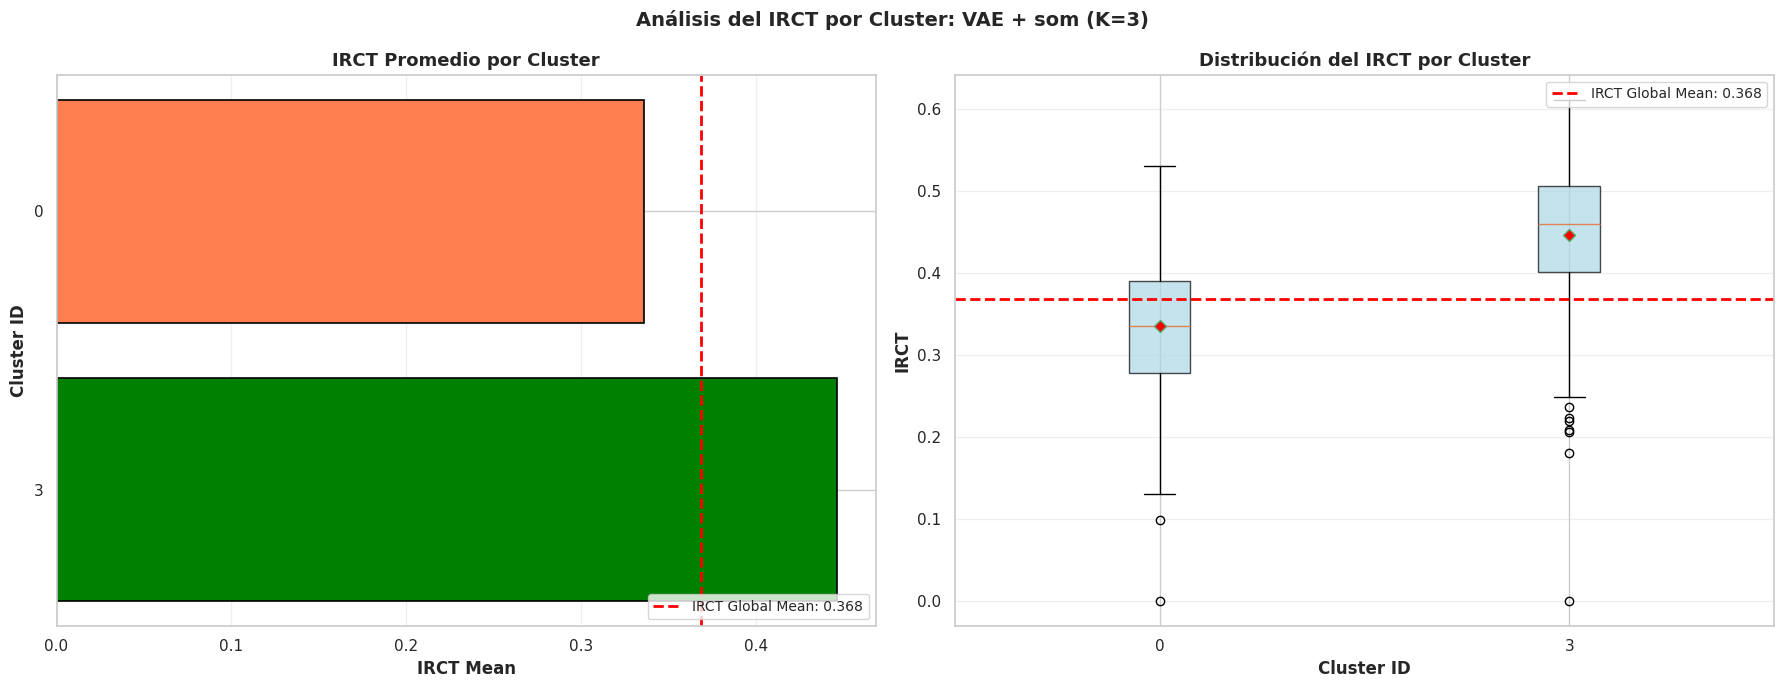


✓ Guardado: /home/aninotna/magister/tesis/justh2_pipeline/plots/clustering_k_sensitivity/best_config_IRCT_by_cluster_VAE_som_k3.png
✓ Tabla guardada: /home/aninotna/magister/tesis/justh2_pipeline/plots/clustering_k_sensitivity/best_config_IRCT_by_cluster_VAE_som_k3.csv


In [39]:
# 6. IRCT POR CLUSTER: Resiliencia promedio de cada cluster
print("\n6. Analizando IRCT por cluster...")

# Usar solo clusters que existen en BASE
unique_clusters_base = np.unique(labels_base)

# Calcular IRCT promedio por cluster en BASE
irt_by_cluster = []
for cluster_id in unique_clusters_base:
    mask = labels_base == cluster_id
    irt_cluster = irt_values[mask]
    
    # Solo procesar si hay píxeles en este cluster
    if len(irt_cluster) > 0:
        irt_by_cluster.append({
            'Cluster': cluster_id,
            'N_Pixels': int(mask.sum()),
            'IRCT_Mean': irt_cluster.mean(),
            'IRCT_Std': irt_cluster.std() if len(irt_cluster) > 1 else 0.0,
            'IRCT_Median': np.median(irt_cluster),
            'IRCT_Q10': np.percentile(irt_cluster, 10) if len(irt_cluster) > 1 else irt_cluster[0],
            'IRCT_Q90': np.percentile(irt_cluster, 90) if len(irt_cluster) > 1 else irt_cluster[0]
        })

df_irt_cluster = pd.DataFrame(irt_by_cluster)
df_irt_cluster = df_irt_cluster.sort_values('IRCT_Mean', ascending=False)

print("\nIRCT por Cluster (ordenado por IRCT_Mean):")
print("="*80)
print(df_irt_cluster.to_string(index=False))

# Visualizar
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Panel 1: IRCT Mean por cluster (barplot)
ax1 = axes[0]
colors_bar = ['green' if x > irt_values.mean() else 'coral' 
              for x in df_irt_cluster['IRCT_Mean']]
bars = ax1.barh(df_irt_cluster['Cluster'].astype(str), df_irt_cluster['IRCT_Mean'], 
                color=colors_bar, edgecolor='black', linewidth=1.2)
ax1.axvline(irt_values.mean(), color='red', linestyle='--', linewidth=2, 
            label=f'IRCT Global Mean: {irt_values.mean():.3f}')
ax1.set_xlabel('IRCT Mean', fontsize=12, fontweight='bold')
ax1.set_ylabel('Cluster ID', fontsize=12, fontweight='bold')
ax1.set_title('IRCT Promedio por Cluster', fontsize=13, fontweight='bold')
ax1.legend(loc='lower right', fontsize=10)
ax1.grid(axis='x', alpha=0.3)

# Panel 2: Boxplot de IRCT por cluster
ax2 = axes[1]
irt_by_cluster_list = [irt_values[labels_base == cluster_id] for cluster_id in unique_clusters_base]
cluster_labels = [str(c) for c in unique_clusters_base]

bp = ax2.boxplot(irt_by_cluster_list, labels=cluster_labels, patch_artist=True,
                 showmeans=True, meanprops=dict(marker='D', markerfacecolor='red', markersize=6))
for patch in bp['boxes']:
    patch.set_facecolor('lightblue')
    patch.set_alpha(0.7)
ax2.axhline(irt_values.mean(), color='red', linestyle='--', linewidth=2,
            label=f'IRCT Global Mean: {irt_values.mean():.3f}')
ax2.set_xlabel('Cluster ID', fontsize=12, fontweight='bold')
ax2.set_ylabel('IRCT', fontsize=12, fontweight='bold')
ax2.set_title('Distribución del IRCT por Cluster', fontsize=13, fontweight='bold')
ax2.legend(loc='upper right', fontsize=10)
ax2.grid(axis='y', alpha=0.3)

plt.suptitle(f'Análisis del IRCT por Cluster: {best_model} + {best_method} (K={best_k})',
             fontsize=14, fontweight='bold')
plt.tight_layout()

output_irt_cluster = os.path.join(PLOTS_DIR, f"best_config_IRCT_by_cluster_{best_model}_{best_method}_k{best_k}.png")
plt.savefig(output_irt_cluster, dpi=300, bbox_inches='tight')
plt.show()
print(f"\n✓ Guardado: {output_irt_cluster}")

# Guardar tabla
output_table = os.path.join(PLOTS_DIR, f"best_config_IRCT_by_cluster_{best_model}_{best_method}_k{best_k}.csv")
df_irt_cluster.to_csv(output_table, index=False)
print(f"✓ Tabla guardada: {output_table}")